# 📈 Matplotlib & Seaborn — Turning Data Into Insight

> **What you'll learn:** how a Matplotlib figure is built, the object-oriented API, which chart answers which question, layouts, annotations, scales, colormaps, styles, and saving; Seaborn's data-first API for distributions, categories, relationships, regressions, heatmaps, and grids; and the plots every ML engineer makes — learning curves, confusion matrices, ROC/PR curves, residuals, feature importance, and 2-D embeddings.

| | |
|---|---|
| **Difficulty** | 🟢 Beginner → 🟡 Intermediate (🔴 ML diagnostic plots) |
| **Time** | ~4 hours to read and run, +2 hours for exercises and the project |
| **Prerequisites** | [Pandas](../01_Core_Scientific_Computing/02_Pandas.ipynb) (DataFrames, groupby) · helpful: [Statistics & Probability](../01_Core_Scientific_Computing/05_Statistics_and_Probability.ipynb) (confidence intervals, correlation) |
| **Tested with** | Python 3.12 · matplotlib 3.11 · seaborn 0.13 · pandas 3.0 · scipy 1.18 · scikit-learn 1.9 |
| **Interview relevance** | ⭐⭐ Medium–High — reading confusion matrices, ROC vs PR curves and learning curves is asked constantly; take-home assignments are judged on clear EDA plots; "which chart would you use?" |

## 🤔 What Is Matplotlib & Seaborn?

Think of building with LEGO:

- **Matplotlib** is the box of **individual bricks**. You can build *anything* — every line, tick, label, and color is yours to control — but you place each brick yourself.
- **Seaborn** is a **LEGO set with instructions** built from the same bricks. Hand it a DataFrame and say "compare body mass across species, coloured by sex" and it builds a good statistical chart in one line.

Because Seaborn draws with Matplotlib, you can always **grab the Matplotlib objects** it returns and fine-tune them. Most real work uses both: Seaborn for the chart, Matplotlib for layout, annotations, and saving.

| Term | Plain-English meaning |
|---|---|
| **Figure** | the whole canvas (the image you save) |
| **Axes** | one plot area with its own x/y coordinate system — a Figure can hold many |
| **Axis** | one ruler (the x-axis or the y-axis) with ticks and a label |
| **Artist** | anything drawn: lines, bars, text, patches, even the Axes itself |
| **Long-form ("tidy") data** | one row per observation, one column per variable — what Seaborn expects |

## 🎯 Why It Matters

- **EDA before modeling.** Distributions, outliers, missing values, and leakage are found by *looking* — a histogram catches a unit bug that a summary table hides.
- **Debugging models.** Learning curves tell you whether to get more data or a bigger model; residual plots reveal a missing feature; a confusion matrix shows *which* mistakes a model makes.
- **Communicating results.** Stakeholders decide from a chart, not from a metrics dictionary. A misleading axis or rainbow colormap can lead to the wrong decision.
- **In interviews** you will be asked to *interpret* ROC vs precision–recall curves, learning curves, and confusion matrices, to pick the right chart for a question, and — in take-home assignments — to produce a clean EDA whose every claim is backed by the data.

## ✅ By the End You Can

- [ ] Explain Figure / Axes / Axis / Artist and write plots with the object-oriented API
- [ ] Choose the right chart for a question and build multi-panel layouts with `layout="constrained"` and `subplot_mosaic`
- [ ] Use annotations, log scales, perceptually uniform and colorblind-safe colors, styles, and export at the right DPI or as vectors
- [ ] Use Seaborn's figure-level and axes-level functions for distributions, categories, relationships, regressions, heatmaps, and grids
- [ ] Draw and interpret learning curves, confusion matrices, ROC/PR curves, residual plots, feature importance, and PCA embeddings
- [ ] Implement a histogram and a Gaussian KDE from scratch and match the libraries exactly

## 📋 Table of Contents

1. [Figure Anatomy and the Object-Oriented API](#1.-Figure-Anatomy-and-the-Object-Oriented-API-🟢)
2. [Core Plot Types](#2.-Core-Plot-Types-🟢)
3. [Choosing the Right Chart for the Question](#3.-Choosing-the-Right-Chart-for-the-Question-🟢)
4. [Subplots and Layout](#4.-Subplots-and-Layout-🟡)
5. [Annotations, Reference Lines, and Text](#5.-Annotations,-Reference-Lines,-and-Text-🟡)
6. [Scales and Axis Formatting](#6.-Scales-and-Axis-Formatting-🟡)
7. [Colors and Colormaps](#7.-Colors-and-Colormaps-🟡)
8. [Styles, Themes, and Saving Figures](#8.-Styles,-Themes,-and-Saving-Figures-🟢)
9. [Seaborn's Data-First API: Axes-Level vs Figure-Level](#9.-Seaborn's-Data-First-API:-Axes-Level-vs-Figure-Level-🟢)
10. [Distributions, Categories, and Relationships](#10.-Distributions,-Categories,-and-Relationships-🟡)
11. [Regression Plots, Heatmaps, and Correlation Matrices](#11.-Regression-Plots,-Heatmaps,-and-Correlation-Matrices-🟡)
12. [Multi-Plot Grids: pairplot, FacetGrid, jointplot](#12.-Multi-Plot-Grids:-pairplot,-FacetGrid,-jointplot-🟡)
13. [Plots Every ML Engineer Makes](#13.-Plots-Every-ML-Engineer-Makes-🔴)
- [🔧 Build It From Scratch](#🔧-Build-It-From-Scratch) · [⚠️ Common Pitfalls](#⚠️-Common-Pitfalls) · [🏋️ Practice Exercises](#🏋️-Practice-Exercises) · [🚀 Mini Project](#🚀-Mini-Project:-A-Data-Driven-EDA-Report-on-the-Titanic) · [🎤 Interview Q&A](#🎤-Interview-Q&A) · [🧪 Quick Quiz](#🧪-Quick-Quiz) · [📚 Resources](#📚-Resources) · [📝 Summary](#📝-Summary-Cheat-Sheet)

## ⚙️ Setup

Run the cell below first. If a package is missing, uncomment the `%pip` line, run it once, then restart the kernel.

- Datasets are **real** and small: seaborn's `penguins`, `tips`, `flights`, `titanic`, `diamonds` (downloaded once from the seaborn-data repository and cached), plus scikit-learn's built-in datasets.
- The `check()` helper gives instant feedback on exercises: **✅** correct, **⏳** not attempted yet, **❌** wrong (with a hint).

In [1]:
# %pip install -q "matplotlib>=3.9" "seaborn>=0.13" "pandas>=2.2" "scipy>=1.14" "scikit-learn>=1.5" "statsmodels>=0.14"

import sys
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import seaborn as sns
import sklearn
from scipy import stats

print(f"Python {sys.version.split()[0]} | Matplotlib {mpl.__version__} | seaborn {sns.__version__} | pandas {pd.__version__} "
      f"| SciPy {scipy.__version__} | scikit-learn {sklearn.__version__}")

rng = np.random.default_rng(42)
OUTPUT_DIR = Path("_outputs")              # saved figures and reports go here (ignored by git)
OUTPUT_DIR.mkdir(exist_ok=True)

penguins = sns.load_dataset("penguins").dropna().reset_index(drop=True)   # 333 penguins with complete measurements
tips = sns.load_dataset("tips")
tips["tip_pct"] = tips["tip"] / tips["total_bill"]
flights = sns.load_dataset("flights")                                     # monthly airline passengers 1949–1960
titanic = sns.load_dataset("titanic")
diamonds = sns.load_dataset("diamonds")
for name, df in {"penguins": penguins, "tips": tips, "flights": flights, "titanic": titanic, "diamonds": diamonds}.items():
    print(f"{name:<9} {df.shape}")


def check(name, got, expected, hint=""):
    """✅ if correct, ⏳ if not attempted yet (None), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return
    if isinstance(expected, (str, dict, set)):
        ok = got == expected
    else:
        got_arr, exp_arr = np.asarray(got), np.asarray(expected)
        if got_arr.shape != exp_arr.shape:
            raise AssertionError(f"❌ {name}: shape {got_arr.shape}, expected {exp_arr.shape}. {hint}")
        numeric = np.issubdtype(exp_arr.dtype, np.number) and exp_arr.dtype != bool
        ok = np.allclose(got_arr.astype(float), exp_arr, rtol=1e-4) if numeric else np.array_equal(got_arr, exp_arr)
    assert ok, f"❌ {name}: not quite (got {got!r}). {hint}"
    print(f"✅ {name}: correct!")

Python 3.12.11 | Matplotlib 3.11.2 | seaborn 0.13.2 | pandas 3.0.5 | SciPy 1.18.1 | scikit-learn 1.9.1
penguins  (333, 7)
tips      (244, 8)
flights   (144, 3)
titanic   (891, 15)
diamonds  (53940, 10)


## 1. Figure Anatomy and the Object-Oriented API 🟢

```
┌──────────────────────────── Figure (the whole image) ────────────────────────────┐
│                               suptitle                                            │
│  ┌───────────── Axes (one plot) ─────────────┐   ┌──────────── Axes ───────────┐  │
│  │  title                          legend    │   │                             │  │
│  │  y Axis ┤  lines, markers, bars, text     │   │                             │  │
│  │         ┤  (all of these are Artists)     │   │                             │  │
│  │         └──────────── x Axis ──────────── │   │                             │  │
│  └───────────────────────────────────────────┘   └─────────────────────────────┘  │
└───────────────────────────────────────────────────────────────────────────────────┘
```

Matplotlib has **two ways** to draw:

| | pyplot "state machine" | Object-oriented (OO) |
|---|---|---|
| Looks like | `plt.plot(x, y); plt.title("…")` | `fig, ax = plt.subplots(); ax.plot(x, y); ax.set_title("…")` |
| Which plot is changed? | whatever is "current" (hidden global state) | exactly the `ax` you name |
| Good for | a quick one-off look | everything else: multiple panels, functions, scripts |

**Rule to remember:** use `plt.subplots()` to create, then call methods on `ax`. Use `plt` only for `plt.subplots()` and `plt.show()`.

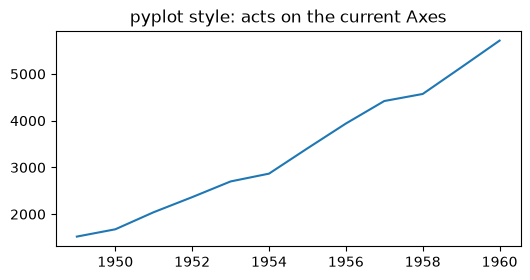

In [2]:
yearly = flights.groupby("year")["passengers"].sum()

# pyplot style: works, but every call silently targets the "current" Axes
plt.figure(figsize=(6, 2.8))
plt.plot(yearly.index, yearly.values)
plt.title("pyplot style: acts on the current Axes")
plt.show()

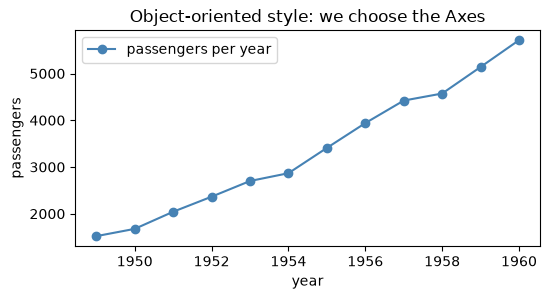

types: Figure, Axes, Line2D
figure size = [6.  2.8] inches × dpi 100 → [600. 280.] pixels
Matplotlib's default dpi is 100 (not 72)
some Artists inside this Axes: ['Legend', 'Line2D', 'Rectangle', 'Spine', 'Text', 'XAxis', 'YAxis']


In [3]:
# Object-oriented style: we hold references to the Figure and the Axes
fig, ax = plt.subplots(figsize=(6, 2.8))
(line,) = ax.plot(yearly.index, yearly.values, marker="o", color="steelblue", label="passengers per year")
ax.set(title="Object-oriented style: we choose the Axes", xlabel="year", ylabel="passengers")
ax.legend()
plt.show()

print(f"types: {type(fig).__name__}, {type(ax).__name__}, {type(line).__name__}")
print(f"figure size = {fig.get_size_inches()} inches × dpi {fig.dpi:.0f} → {fig.get_size_inches() * fig.dpi} pixels")
print(f"Matplotlib's default dpi is {mpl.rcParamsDefault['figure.dpi']:.0f} (not 72)")
print(f"some Artists inside this Axes: {sorted({type(a).__name__ for a in ax.get_children()})}")

The OO style shines when you write **reusable plotting functions that take an `ax`** — the same function can fill any panel of any figure.

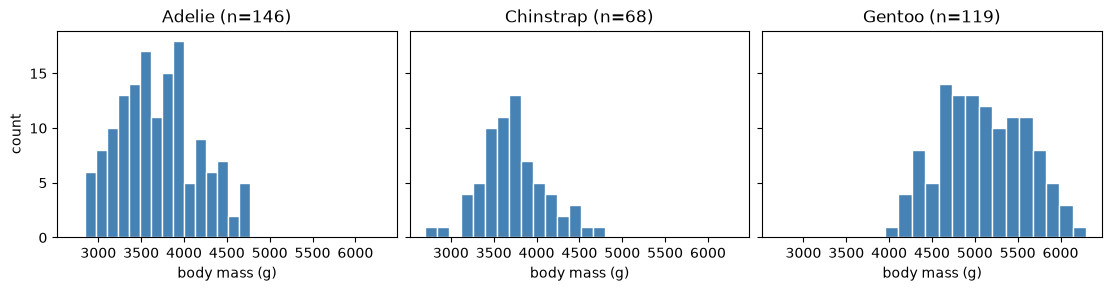

In [4]:
def plot_mass_hist(ax, species):
    data = penguins.loc[penguins["species"] == species, "body_mass_g"]
    ax.hist(data, bins=15, color="steelblue", edgecolor="white")
    ax.set(title=f"{species} (n={len(data)})", xlabel="body mass (g)")
    return ax


fig, axes = plt.subplots(1, 3, figsize=(11, 2.8), sharex=True, sharey=True, layout="constrained")
for ax, species in zip(axes, penguins["species"].unique()):
    plot_mass_hist(ax, species)
axes[0].set_ylabel("count")
plt.show()

### ✍️ Your Turn

Create a Figure and Axes named `ax_turn`, plot `yearly` as a line, set the title to **"Airline passengers per year"** and the y-label to **"passengers"**.

In [5]:
ax_turn = None  # TODO: fig, ax_turn = plt.subplots(...); ax_turn.plot(...); ax_turn.set(...)
check("title", None if ax_turn is None else ax_turn.get_title(), "Airline passengers per year", hint="ax_turn.set_title(...) or ax_turn.set(title=...)")
check("ylabel", None if ax_turn is None else ax_turn.get_ylabel(), "passengers", hint="ax_turn.set_ylabel('passengers')")

⏳ title: not attempted yet — replace None with your answer.
⏳ ylabel: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
fig, ax_turn = plt.subplots(figsize=(6, 2.8))
ax_turn.plot(yearly.index, yearly.values, marker="o")
ax_turn.set(title="Airline passengers per year", xlabel="year", ylabel="passengers")
plt.show()
check("title", ax_turn.get_title(), "Airline passengers per year")
check("ylabel", ax_turn.get_ylabel(), "passengers")
```
</details>

> 💡 **Interview angle:** "Figure vs Axes vs Axis?" — a Figure is the canvas, an Axes is one plot inside it (with two Axis rulers), everything drawn is an Artist. Say you use the OO API because explicit `ax` handles avoid hidden global state and make plotting functions reusable and testable.

## 2. Core Plot Types 🟢

Six plot types cover most real work. All six below use real data.

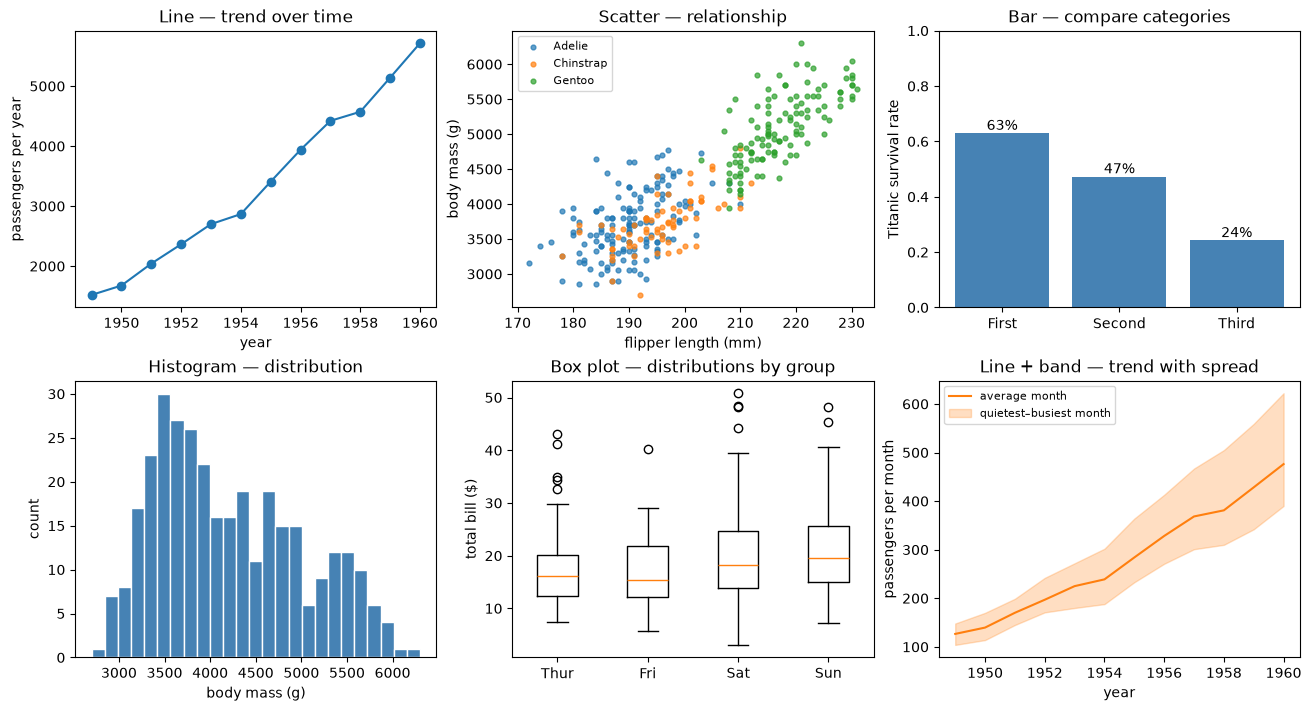

In [6]:
survival_by_class = titanic.groupby("class", observed=True)["survived"].mean()
days = ["Thur", "Fri", "Sat", "Sun"]
monthly_range = flights.groupby("year")["passengers"].agg(["mean", "min", "max"])

fig, axes = plt.subplots(2, 3, figsize=(13, 7), layout="constrained")

axes[0, 0].plot(yearly.index, yearly.values, marker="o")
axes[0, 0].set(title="Line — trend over time", xlabel="year", ylabel="passengers per year")

for species, grp in penguins.groupby("species"):
    axes[0, 1].scatter(grp["flipper_length_mm"], grp["body_mass_g"], s=12, alpha=0.7, label=species)
axes[0, 1].set(title="Scatter — relationship", xlabel="flipper length (mm)", ylabel="body mass (g)")
axes[0, 1].legend(fontsize=8)

bars = axes[0, 2].bar(survival_by_class.index.astype(str), survival_by_class.values, color="steelblue")
axes[0, 2].bar_label(bars, fmt="{:.0%}")
axes[0, 2].set(title="Bar — compare categories", ylabel="Titanic survival rate", ylim=(0, 1))

axes[1, 0].hist(penguins["body_mass_g"], bins=25, color="steelblue", edgecolor="white")
axes[1, 0].set(title="Histogram — distribution", xlabel="body mass (g)", ylabel="count")

axes[1, 1].boxplot([tips.loc[tips["day"] == d, "total_bill"] for d in days], tick_labels=days)
axes[1, 1].set(title="Box plot — distributions by group", ylabel="total bill ($)")

axes[1, 2].plot(monthly_range.index, monthly_range["mean"], color="C1", label="average month")
axes[1, 2].fill_between(monthly_range.index, monthly_range["min"], monthly_range["max"], color="C1", alpha=0.25, label="quietest–busiest month")
axes[1, 2].set(title="Line + band — trend with spread", xlabel="year", ylabel="passengers per month")
axes[1, 2].legend(fontsize=8)
plt.show()

**Reading a box plot:** the box spans Q1 to Q3 (the middle 50%), the line inside is the median, whiskers reach the furthest points within 1.5 × IQR of the box, and dots beyond are potential outliers.

> 💡 **Interview angle:** "What does a box plot hide?" — the shape: two very different distributions (e.g. bimodal vs uniform) can have identical boxes. Pair it with points (strip plot) or use a violin/histogram when shape matters.

## 3. Choosing the Right Chart for the Question 🟢

Start from the **question**, not the chart type.

| Question | Good choice | Avoid |
|---|---|---|
| How is one numeric variable distributed? | histogram, KDE, ECDF, box/violin by group | a bar of means (hides spread) |
| How do categories compare? | **sorted** bar chart, dot plot | pie with many slices, 3-D bars |
| How does something change over time? | line chart | bars for dense time series |
| How do two numeric variables relate? | scatter (+ trend line; transparency or hexbin for many points) | lines connecting unordered points |
| What is part of a whole? | stacked or 100% bar | pie charts beyond 2–3 slices |
| Many variables at once? | heatmap, pair plot, small multiples | one crowded chart with 10 colours |

Our eyes compare **lengths along a common baseline** far more accurately than **angles or areas**. Same numbers, two charts — which three clarity grades are most common, and in what order?

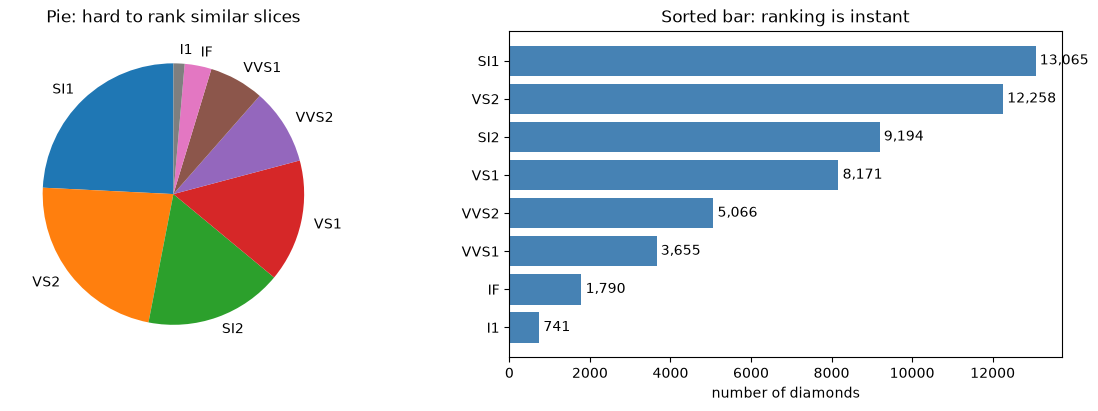

top 3 clarity grades: SI1 (13,065), VS2 (12,258), SI2 (9,194)
#1 and #2 differ by 807 diamonds: only 5° of pie angle, but a 7% difference in bar length on a shared baseline


In [7]:
clarity_counts = diamonds["clarity"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
axes[0].pie(clarity_counts.values, labels=clarity_counts.index.astype(str), startangle=90)
axes[0].set_title("Pie: hard to rank similar slices")
sorted_counts = clarity_counts.sort_values()
axes[1].barh(sorted_counts.index.astype(str), sorted_counts.values, color="steelblue")
axes[1].bar_label(axes[1].containers[0], fmt="{:,.0f}", padding=3)
axes[1].set(title="Sorted bar: ranking is instant", xlabel="number of diamonds")
plt.show()

top3 = clarity_counts.head(3)
print("top 3 clarity grades:", ", ".join(f"{grade} ({count:,})" for grade, count in top3.items()))
gap_12 = top3.iloc[0] - top3.iloc[1]
print(f"#1 and #2 differ by {gap_12:,} diamonds: only {360 * gap_12 / len(diamonds):.0f}° of pie angle, "
      f"but a {gap_12 / top3.iloc[1]:.0%} difference in bar length on a shared baseline")

### ✍️ Your Turn

Fill in the best chart for each question, choosing from `"histogram"`, `"line"`, `"scatter"`, `"bar"`.

In [8]:
chart_for = {
    "distribution of penguin body mass": None,
    "monthly airline passengers from 1949 to 1960": None,
    "bill length vs bill depth": None,
    "average tip per day of the week": None,
}  # TODO: replace each None
check("chart_for", None if None in chart_for.values() else chart_for,
      {"distribution of penguin body mass": "histogram", "monthly airline passengers from 1949 to 1960": "line",
       "bill length vs bill depth": "scatter", "average tip per day of the week": "bar"},
      hint="distribution → histogram, time → line, two numeric → scatter, compare categories → bar")

⏳ chart_for: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
chart_for = {
    "distribution of penguin body mass": "histogram",
    "monthly airline passengers from 1949 to 1960": "line",
    "bill length vs bill depth": "scatter",
    "average tip per day of the week": "bar",
}
check("chart_for", chart_for,
      {"distribution of penguin body mass": "histogram", "monthly airline passengers from 1949 to 1960": "line",
       "bill length vs bill depth": "scatter", "average tip per day of the week": "bar"})
```
For "average tip per day", a bar (or dot) chart *with error bars* is even better — an average without its uncertainty invites over-reading small differences.
</details>

> 💡 **Interview angle:** "Which chart would you use to show X?" — name the question type first (distribution / comparison / trend / relationship / composition), then the chart, then one thing you'd avoid and why (e.g. dual y-axes can suggest correlations that the scaling creates).

## 4. Subplots and Layout 🟡

- `plt.subplots(nrows, ncols, sharex=…, sharey=…)` returns an **array of Axes** (`axes[row, col]`, or loop over `axes.flat`).
- `layout="constrained"` automatically makes room for titles, labels, legends, and colorbars. It replaces the older `plt.tight_layout()` and handles colorbars and suptitles better.
- `plt.subplot_mosaic` builds irregular dashboards from a picture of the layout and gives you Axes **by name**.

Let's measure the difference layout makes by counting overlapping panels.

layout=None: 4 overlapping panel pairs


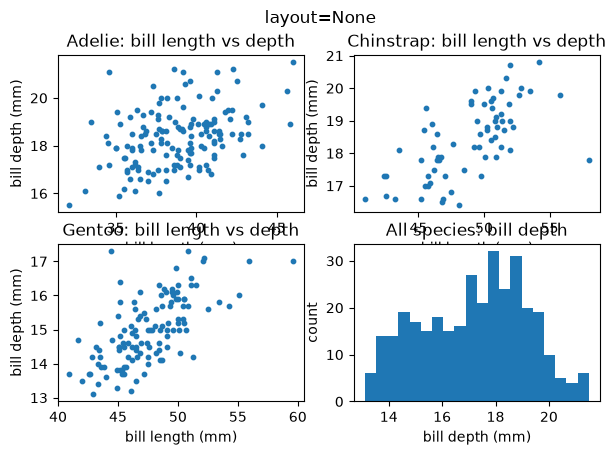

layout='constrained': 0 overlapping panel pairs


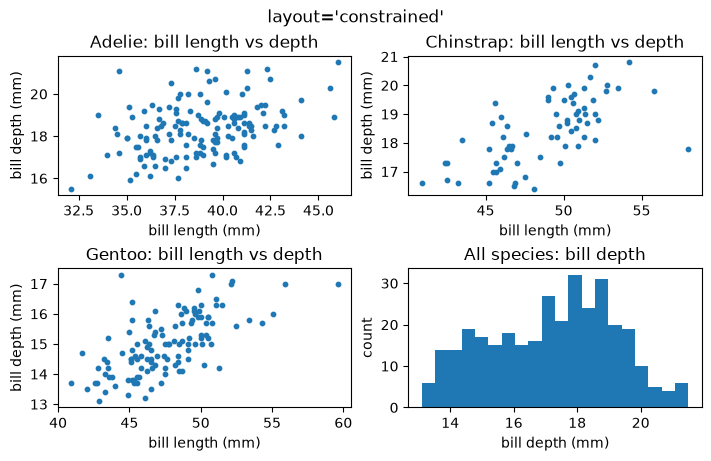

In [9]:
def count_overlaps(fig, axes):
    fig.canvas.draw()                                               # run the layout engine so positions are final
    renderer = fig.canvas.get_renderer()
    boxes = [ax.get_tightbbox(renderer) for ax in axes.flat]        # each Axes including its labels and title
    return sum(a.overlaps(b) for i, a in enumerate(boxes) for b in boxes[i + 1:])


for layout in (None, "constrained"):
    fig, axes = plt.subplots(2, 2, figsize=(7, 4.5), layout=layout)
    for ax, (species, grp) in zip(axes.flat, penguins.groupby("species")):
        ax.scatter(grp["bill_length_mm"], grp["bill_depth_mm"], s=10)
        ax.set(title=f"{species}: bill length vs depth", xlabel="bill length (mm)", ylabel="bill depth (mm)")
    axes[1, 1].hist(penguins["bill_depth_mm"], bins=20)
    axes[1, 1].set(title="All species: bill depth", xlabel="bill depth (mm)", ylabel="count")
    fig.suptitle(f"layout={layout!r}")
    print(f"layout={layout!r}: {count_overlaps(fig, axes)} overlapping panel pairs")
    plt.show()

**`subplot_mosaic`** — draw the layout as a list of rows; repeating a name makes that panel span cells.

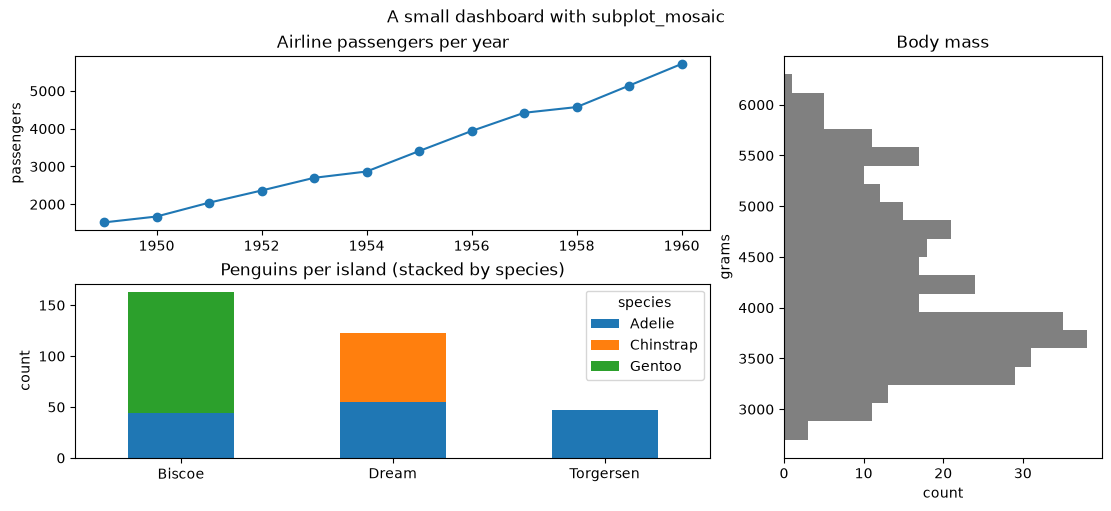

panels by name: ['island', 'mass', 'trend']


In [10]:
fig, axd = plt.subplot_mosaic(
    [["trend", "trend", "mass"],
     ["island", "island", "mass"]],
    figsize=(11, 5), layout="constrained",
)
axd["trend"].plot(yearly.index, yearly.values, marker="o")
axd["trend"].set(title="Airline passengers per year", ylabel="passengers")

island_counts = penguins.groupby(["island", "species"]).size().unstack(fill_value=0)
island_counts.plot.bar(stacked=True, ax=axd["island"], rot=0)              # pandas plotting draws on our Axes
axd["island"].set(title="Penguins per island (stacked by species)", xlabel="", ylabel="count")

axd["mass"].hist(penguins["body_mass_g"], bins=20, orientation="horizontal", color="gray")
axd["mass"].set(title="Body mass", xlabel="count", ylabel="grams")
fig.suptitle("A small dashboard with subplot_mosaic")
plt.show()
print("panels by name:", sorted(axd))

> 💡 **Interview angle:** "Labels overlap or get cut off when you save a figure — how do you fix it?" — create the figure with `layout="constrained"` (or call `fig.tight_layout()`), and save with `bbox_inches="tight"` if labels still fall outside the canvas.

## 5. Annotations, Reference Lines, and Text 🟡

Every Artist is positioned in some **coordinate system**:

| Coordinates | Meaning | Example |
|---|---|---|
| **data** (default) | the values on your axes | `ax.annotate("peak", xy=(date, 622))` |
| **axes fraction** `transform=ax.transAxes` | (0, 0) bottom-left → (1, 1) top-right of the Axes | a label in the corner: `ax.text(0.02, 0.95, …, transform=ax.transAxes)` |
| **mixed** | `ax.axhline(y)` → y in data, x spans the Axes (`xmin`/`xmax` are fractions) | a target line |

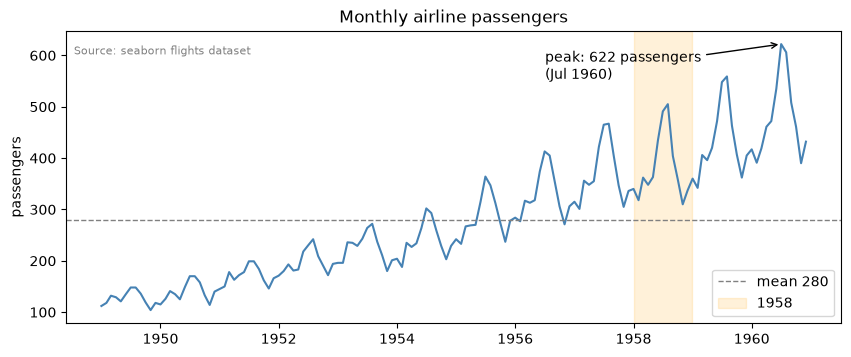

peak month: July 1960 with 622 passengers | yearly total grew 3.8× from 1949 to 1960


In [11]:
flights_dated = flights.assign(date=pd.to_datetime(flights["year"].astype(str) + "-" + flights["month"].astype(str), format="%Y-%b"))
peak = flights_dated.loc[flights_dated["passengers"].idxmax()]
overall_mean = flights_dated["passengers"].mean()

fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(flights_dated["date"], flights_dated["passengers"], color="steelblue")
ax.axhline(overall_mean, color="gray", ls="--", lw=1, label=f"mean {overall_mean:.0f}")           # data y, full width
ax.axvspan(pd.Timestamp("1958-01-01"), pd.Timestamp("1958-12-31"), color="orange", alpha=0.15, label="1958")
ax.annotate(f"peak: {peak['passengers']} passengers\n({peak['date']:%b %Y})",
            xy=(peak["date"], peak["passengers"]), xytext=(-170, -25), textcoords="offset points",
            arrowprops={"arrowstyle": "->", "color": "black"})
ax.text(0.01, 0.95, "Source: seaborn flights dataset", transform=ax.transAxes, va="top", fontsize=8, color="gray")
ax.set(title="Monthly airline passengers", ylabel="passengers")
ax.legend(loc="lower right")
plt.show()

growth = yearly.iloc[-1] / yearly.iloc[0]
print(f"peak month: {peak['date']:%B %Y} with {peak['passengers']} passengers | yearly total grew {growth:.1f}× from {yearly.index[0]} to {yearly.index[-1]}")

`ax.bar_label` writes values on bars; its `fmt` accepts a **format string with braces** such as `"{:.1%}"`. (An old-style `"%.1%%"` does not produce a percentage.)

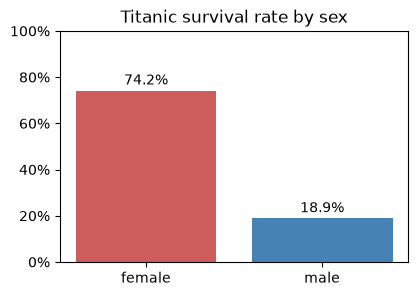

bar labels: ['74.2%', '18.9%']


In [12]:
survival_by_sex = titanic.groupby("sex")["survived"].mean()
fig, ax = plt.subplots(figsize=(4.5, 3))
bars = ax.bar(survival_by_sex.index, survival_by_sex.values, color=["indianred", "steelblue"])
labels = ax.bar_label(bars, fmt="{:.1%}", padding=2)
ax.set(title="Titanic survival rate by sex", ylim=(0, 1))
ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=1))
plt.show()
print("bar labels:", [t.get_text() for t in labels])

> 💡 **Interview angle:** Good annotation answers the viewer's first question on the chart itself ("what's that spike?"). Mention **data vs axes coordinates** — it's the root of many "my text disappeared" bugs.

## 6. Scales and Axis Formatting 🟡

When data span several orders of magnitude (prices, incomes, latencies, word counts), a **linear** axis squashes most points into a corner. A **log scale** spaces 10, 100, 1,000 equally, so multiplicative patterns become straight lines.

- `ax.set_xscale("log")` for strictly positive data; use **log-spaced bins** (`np.geomspace`) for histograms.
- `"symlog"` handles zeros and negatives (linear near zero, log further out).
- Tick formatters make numbers readable: `StrMethodFormatter("${x:,.0f}")`, `PercentFormatter(xmax=1)`.

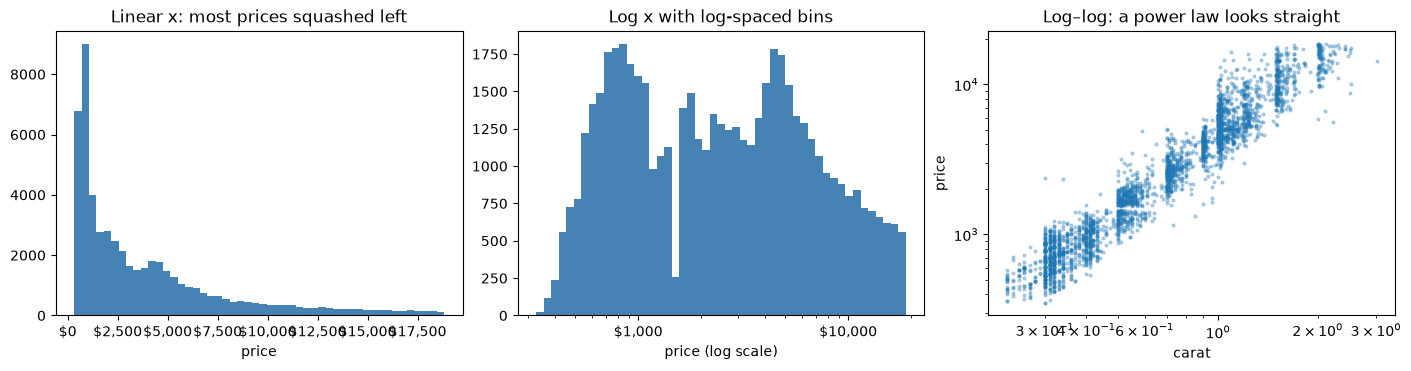

price skewness: linear 1.62 → log10 0.12
log–log slope = 1.68 → price grows roughly like carat^1.7 (doubling carat multiplies price by ≈ 3.2)


In [13]:
from matplotlib.ticker import StrMethodFormatter

price = diamonds["price"]
sample = diamonds.sample(3_000, random_state=0)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6), layout="constrained")
axes[0].hist(price, bins=50, color="steelblue")
axes[0].set(title="Linear x: most prices squashed left", xlabel="price")
axes[0].xaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))

axes[1].hist(price, bins=np.geomspace(price.min(), price.max(), 50), color="steelblue")
axes[1].set_xscale("log")
axes[1].set(title="Log x with log-spaced bins", xlabel="price (log scale)")
axes[1].xaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))

axes[2].scatter(sample["carat"], sample["price"], s=4, alpha=0.3)
axes[2].set(xscale="log", yscale="log", title="Log–log: a power law looks straight", xlabel="carat", ylabel="price")
plt.show()

slope, intercept = np.polyfit(np.log10(diamonds["carat"]), np.log10(diamonds["price"]), deg=1)
print(f"price skewness: linear {stats.skew(price):.2f} → log10 {stats.skew(np.log10(price)):.2f}")
print(f"log–log slope = {slope:.2f} → price grows roughly like carat^{slope:.1f} (doubling carat multiplies price by ≈ {2 ** slope:.1f})")

### ✍️ Your Turn

Scatter `sample["carat"]` against `sample["price"]` on a new Axes `ax_scale` and make **both** axes logarithmic.

In [14]:
ax_scale = None  # TODO
check("log scales", None if ax_scale is None else (ax_scale.get_xscale(), ax_scale.get_yscale()), ("log", "log"),
      hint="ax_scale.set_xscale('log') and ax_scale.set_yscale('log'), or ax_scale.set(xscale='log', yscale='log')")

⏳ log scales: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
fig, ax_scale = plt.subplots(figsize=(5, 3.5))
ax_scale.scatter(sample["carat"], sample["price"], s=4, alpha=0.3)
ax_scale.set(xscale="log", yscale="log", xlabel="carat", ylabel="price")
plt.show()
check("log scales", (ax_scale.get_xscale(), ax_scale.get_yscale()), ("log", "log"))
```
</details>

> 💡 **Interview angle:** "Your loss curve looks flat after epoch 5 — is training done?" — plot the loss on a **log y-axis**; improvements from 0.01 to 0.001 are invisible on a linear scale.

## 7. Colors and Colormaps 🟡

| Kind | Use for | Examples |
|---|---|---|
| **Sequential** | ordered values, low → high | `viridis`, `magma`, `cividis`, `Blues` |
| **Diverging** | values around a meaningful midpoint (0 correlation, ± change) | `vlag`, `RdBu`, `coolwarm` — with symmetric limits |
| **Qualitative** | unordered categories | `tab10`, seaborn `"colorblind"`, `Set2` |

A good sequential colormap is **perceptually uniform**: equal steps in value look like equal steps in colour, and **lightness increases steadily**, so it still works in grayscale and for most colour-vision deficiencies (~1 in 12 men has one). The old `jet` rainbow fails this — its lightness goes up *and down*, creating bright bands that look like boundaries in smooth data.

We approximate perceived lightness with **luma** (a weighted sum of R, G, B) and check whether it rises monotonically.

 viridis: lightness always increasing? True
 cividis: lightness always increasing? True
     jet: lightness always increasing? False
   turbo: lightness always increasing? False


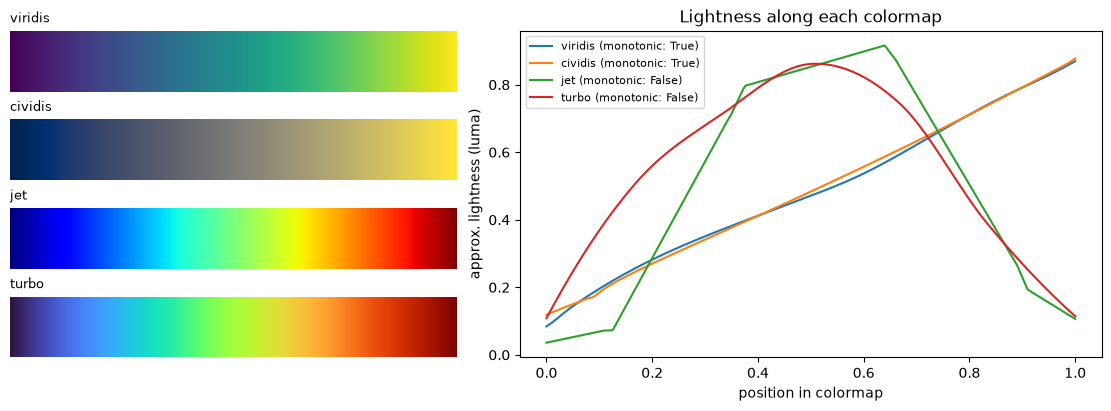

In [15]:
luma_weights = np.array([0.2126, 0.7152, 0.0722])                     # Rec. 709 weights: green looks brightest
names = ["viridis", "cividis", "jet", "turbo"]
gradient = np.linspace(0, 1, 256)[None, :]

fig, axd = plt.subplot_mosaic([[n, "luma"] for n in names], figsize=(11, 4), layout="constrained", width_ratios=[1, 1.3])
for name in names:
    cmap = mpl.colormaps[name]
    axd[name].imshow(gradient, aspect="auto", cmap=cmap)
    axd[name].set_axis_off()
    axd[name].set_title(name, fontsize=9, loc="left")
    luma = cmap(np.linspace(0, 1, 256))[:, :3] @ luma_weights
    monotonic = bool(np.all(np.diff(luma) > 0))
    axd["luma"].plot(np.linspace(0, 1, 256), luma, label=f"{name} (monotonic: {monotonic})")
    print(f"{name:>8}: lightness always increasing? {monotonic}")
axd["luma"].set(xlabel="position in colormap", ylabel="approx. lightness (luma)", title="Lightness along each colormap")
axd["luma"].legend(fontsize=8)
plt.show()

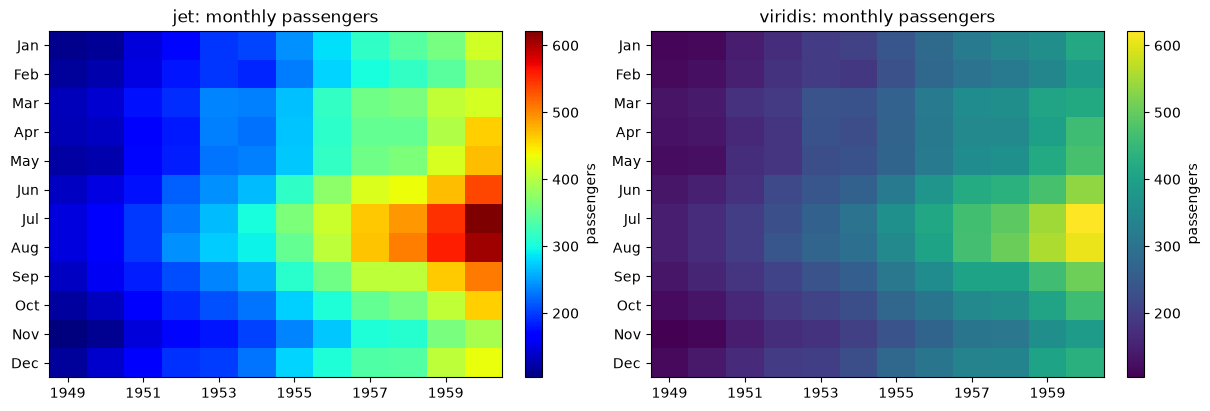

In [16]:
passengers_grid = flights.pivot(index="month", columns="year", values="passengers")
fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
for ax, cmap_name in zip(axes, ["jet", "viridis"]):
    image = ax.imshow(passengers_grid, cmap=cmap_name, aspect="auto")
    ax.set(title=f"{cmap_name}: monthly passengers", xticks=range(0, 12, 2), xticklabels=passengers_grid.columns[::2],
           yticks=range(12), yticklabels=passengers_grid.index.astype(str))
    fig.colorbar(image, ax=ax, label="passengers")
plt.show()

**Categories and colour-vision deficiency:** use a colorblind-friendly qualitative palette **and** a second cue (marker shape or line style), so the chart never relies on colour alone.

seaborn 'colorblind' palette: ['#0173b2', '#de8f05', '#029e73', '#d55e00', '#cc78bc', '#ca9161']


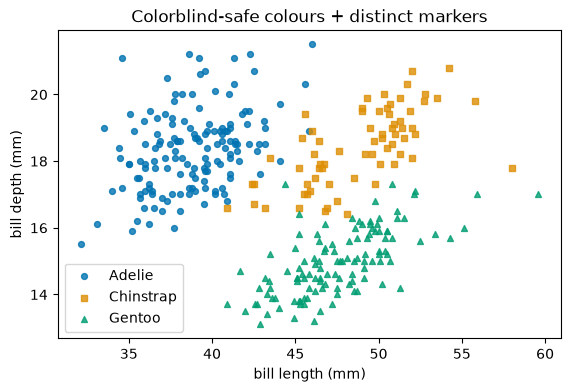

In [17]:
cb_palette = sns.color_palette("colorblind")
print("seaborn 'colorblind' palette:", cb_palette.as_hex()[:6])
markers = {"Adelie": "o", "Chinstrap": "s", "Gentoo": "^"}

fig, ax = plt.subplots(figsize=(6.5, 4))
for color, (species, grp) in zip(cb_palette, penguins.groupby("species")):
    ax.scatter(grp["bill_length_mm"], grp["bill_depth_mm"], color=color, marker=markers[species], s=18, alpha=0.8, label=species)
ax.set(title="Colorblind-safe colours + distinct markers", xlabel="bill length (mm)", ylabel="bill depth (mm)")
ax.legend()
plt.show()

Access colormaps with `mpl.colormaps["viridis"]` (the old `matplotlib.cm.get_cmap` was removed in Matplotlib 3.9), and get *k* evenly spaced colours with `mpl.colormaps["viridis"].resampled(k)`.

> 💡 **Interview angle:** "Why did Matplotlib replace `jet` with `viridis` as the default?" — viridis is perceptually uniform with monotonically increasing lightness, readable in grayscale and by most colour-blind viewers; jet's lightness bands create fake features.

## 8. Styles, Themes, and Saving Figures 🟢

**Styles** are bundles of default settings (`rcParams`): fonts, colours, grid, background.

- `plt.style.context("ggplot")` applies a style **only to figures created inside the `with` block**. Axes created earlier keep their old look.
- Seaborn has themes for the same purpose: `sns.set_theme(style="whitegrid")` (global) or `with sns.axes_style("darkgrid"), sns.plotting_context("talk"):` (temporary). `talk`/`poster` enlarge fonts for slides.

28 built-in styles, e.g. ['Solarize_Light2', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight']
Axes background inside the ggplot context: #e5e5e5


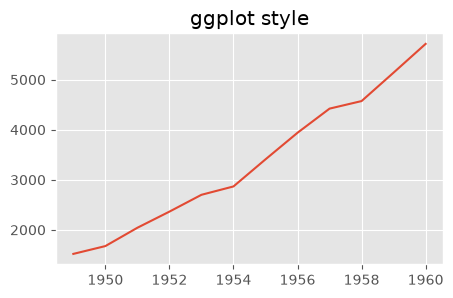

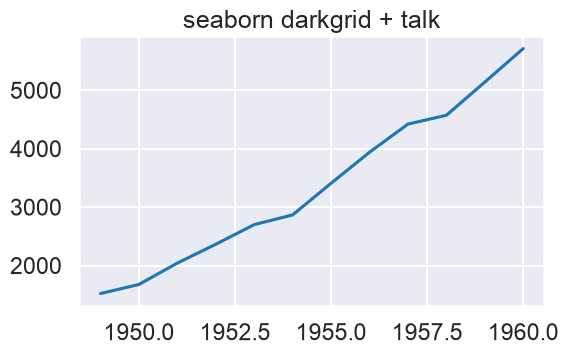

Axes background after leaving the contexts: #ffffff


In [18]:
print(f"{len(plt.style.available)} built-in styles, e.g. {plt.style.available[:6]}")

with plt.style.context("ggplot"):
    fig, ax = plt.subplots(figsize=(5, 3))                        # created INSIDE the context → styled
    ax.plot(yearly.index, yearly.values)
    ax.set_title("ggplot style")
    print(f"Axes background inside the ggplot context: {mpl.colors.to_hex(ax.get_facecolor())}")
    plt.show()

with sns.axes_style("darkgrid"), sns.plotting_context("talk"):
    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.plot(yearly.index, yearly.values)
    ax.set_title("seaborn darkgrid + talk")
    plt.show()

fig, ax = plt.subplots(figsize=(5, 3))
print(f"Axes background after leaving the contexts: {mpl.colors.to_hex(ax.get_facecolor())}")
plt.close(fig)

### Saving: raster vs vector

- **PNG (raster)** stores pixels: pixel size = `figsize` (inches) × `dpi`. Use ~150–300 dpi for reports; Matplotlib's default is **100 dpi**.
- **SVG / PDF (vector)** store shapes: sharp at any zoom, ideal for papers and slides (but huge scatter plots become heavy — rasterize those with `rasterized=True`).
- `bbox_inches="tight"` trims empty margins (and changes the pixel size).

In [19]:
from PIL import Image

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(yearly.index, yearly.values, marker="o")
ax.set(title="Saved four ways", xlabel="year", ylabel="passengers")
outputs = {"chart_100dpi.png": {"dpi": 100}, "chart_300dpi.png": {"dpi": 300}, "chart_tight_300dpi.png": {"dpi": 300, "bbox_inches": "tight"},
           "chart.svg": {}, "chart.pdf": {}}
for filename, kwargs in outputs.items():
    fig.savefig(OUTPUT_DIR / filename, **kwargs)
plt.close(fig)                                                       # free memory — important when saving in a loop

for filename in outputs:
    path = OUTPUT_DIR / filename
    pixels = Image.open(path).size if path.suffix == ".png" else "vector (no pixel grid)"
    print(f"{filename:<24} {path.stat().st_size / 1024:7.1f} KB   {pixels}")

chart_100dpi.png            20.6 KB   (600, 400)


chart_300dpi.png            75.9 KB   (1800, 1200)
chart_tight_300dpi.png      76.1 KB   (1650, 1176)
chart.svg                   24.0 KB   vector (no pixel grid)
chart.pdf                   11.9 KB   vector (no pixel grid)


> 💡 **Interview angle:** "A chart looks blurry in the slide deck." — it was saved as a low-dpi PNG and scaled up; save at higher dpi or as SVG/PDF. Also `plt.close(fig)` after saving inside loops, or a batch job will leak memory ("More than 20 figures have been opened").

## 9. Seaborn's Data-First API: Axes-Level vs Figure-Level 🟢

Seaborn works best with **long-form data**: one row per observation, one column per variable. You describe *what* to map, not *how* to draw it:

`sns.scatterplot(data=penguins, x="bill_length_mm", y="bill_depth_mm", hue="species", style="sex")`

Seaborn functions come in two kinds:

| Family | **Axes-level** (draws on one `ax`, returns it) | **Figure-level** (makes its own figure, returns a `FacetGrid`) |
|---|---|---|
| Relational | `scatterplot`, `lineplot` | `relplot` |
| Distributions | `histplot`, `kdeplot`, `ecdfplot`, `rugplot` | `displot` |
| Categorical | `stripplot`, `swarmplot`, `boxplot`, `violinplot`, `boxenplot`, `pointplot`, `barplot`, `countplot` | `catplot` |
| Regression | `regplot` | `lmplot` |
| Matrix / multi-variable | `heatmap` | `pairplot`, `jointplot`, `clustermap` |

- **Axes-level:** fits into your own `plt.subplots` / mosaic layouts. Size comes from your figure.
- **Figure-level:** one call makes **small multiples** with `col=` / `row=`. Size with `height=` and `aspect=` (not `figsize`); reach the Matplotlib objects via `g.figure` and `g.axes`.

From here on we use seaborn's clean `whitegrid` theme.

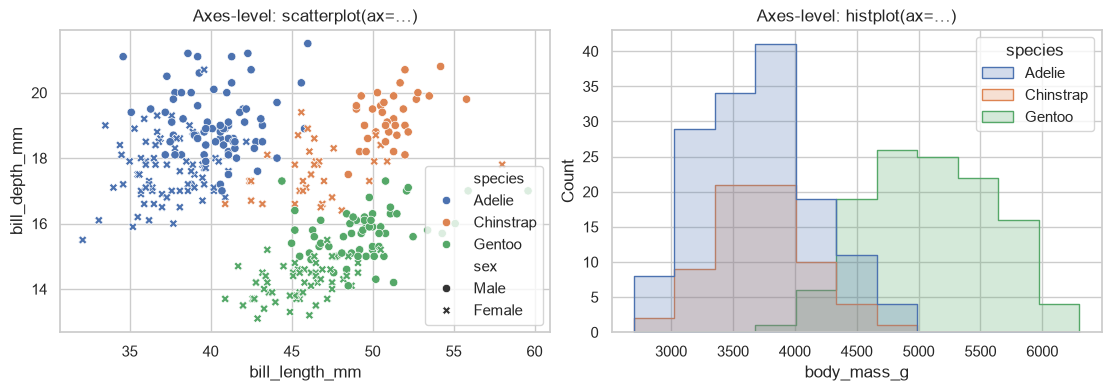

In [20]:
sns.set_theme(style="whitegrid")

# Axes-level: we control the layout
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), layout="constrained")
sns.scatterplot(data=penguins, x="bill_length_mm", y="bill_depth_mm", hue="species", style="sex", ax=axes[0])
axes[0].set_title("Axes-level: scatterplot(ax=…)")
sns.histplot(data=penguins, x="body_mass_g", hue="species", element="step", ax=axes[1])
axes[1].set_title("Axes-level: histplot(ax=…)")
plt.show()

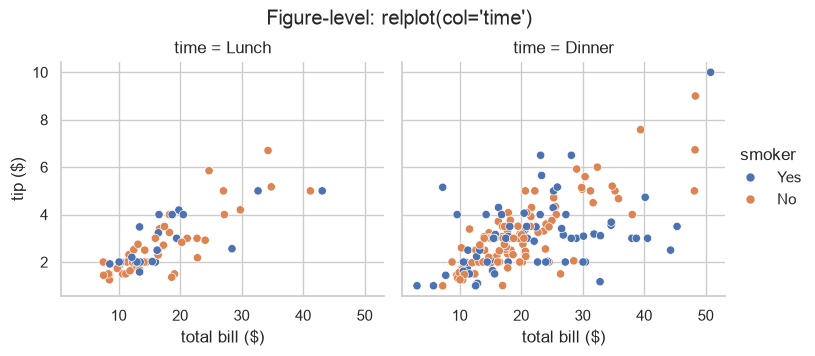

returned FacetGrid with axes grid (1, 2); figure size [8.2759375 3.4      ] inches


In [21]:
# Figure-level: one call → a grid of Axes, one column per value of `time`
g = sns.relplot(data=tips, x="total_bill", y="tip", hue="smoker", col="time", height=3.4, aspect=1.1)
g.set_axis_labels("total bill ($)", "tip ($)")
g.figure.suptitle("Figure-level: relplot(col='time')", y=1.04)
plt.show()
print(f"returned {type(g).__name__} with axes grid {g.axes.shape}; figure size {g.figure.get_size_inches()} inches")

> 💡 **Interview angle:** "Why does `figsize` not work with `sns.catplot`?" — figure-level functions create their own figure; size them with `height` and `aspect`, and customize through `g.figure` / `g.axes`. Use axes-level functions when the plot must live inside an existing layout.

## 10. Distributions, Categories, and Relationships 🟡

### Distributions

- **Histogram** — counts in bins (shape depends on bin width).
- **KDE** — a smooth curve made by summing little bell curves (we build one from scratch later); can spill past natural limits like 0.
- **ECDF** — for each value, the share of data ≤ it; no bins, no smoothing, easy to read medians and percentiles.

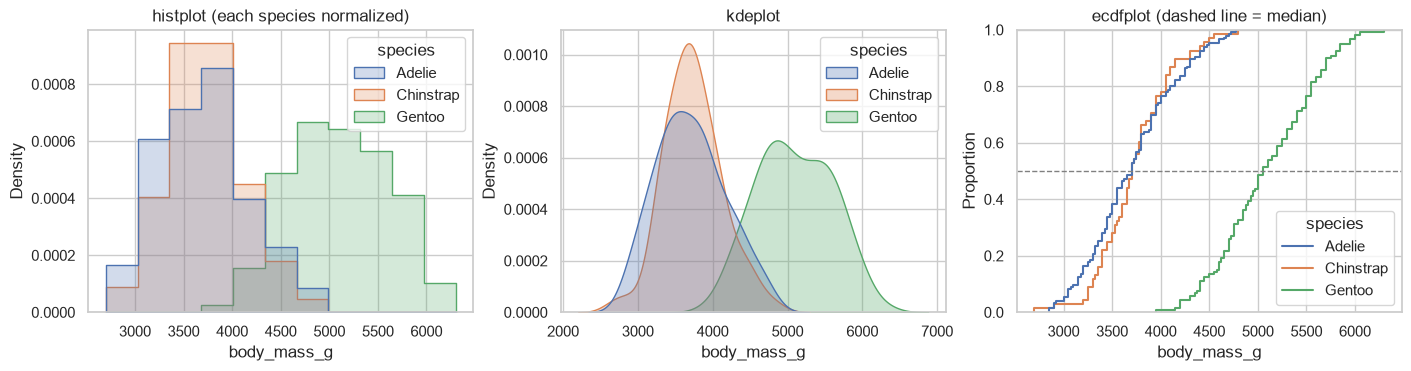

median body mass: Adelie 3,700 g, Chinstrap 3,700 g, Gentoo 5,050 g
→ Gentoo penguins are heaviest, 1,350 g above Chinstrap


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6), layout="constrained")
sns.histplot(data=penguins, x="body_mass_g", hue="species", stat="density", common_norm=False, element="step", ax=axes[0])
axes[0].set_title("histplot (each species normalized)")
sns.kdeplot(data=penguins, x="body_mass_g", hue="species", fill=True, common_norm=False, alpha=0.3, ax=axes[1])
axes[1].set_title("kdeplot")
sns.ecdfplot(data=penguins, x="body_mass_g", hue="species", ax=axes[2])
axes[2].axhline(0.5, color="gray", ls="--", lw=1)
axes[2].set_title("ecdfplot (dashed line = median)")
plt.show()

medians = penguins.groupby("species")["body_mass_g"].median().sort_values()
print("median body mass:", ", ".join(f"{s} {m:,.0f} g" for s, m in medians.items()))
print(f"→ {medians.index[-1]} penguins are heaviest, {medians.iloc[-1] - medians.iloc[-2]:,.0f} g above {medians.index[-2]}")

### Categorical plots

- **Distribution per category:** `violinplot`, `boxenplot`, `stripplot` (all points).
- **Estimate per category:** `barplot` / `pointplot` show a **mean with a 95% confidence interval** (bootstrapped) — not the spread of the data.
- **Counts:** `countplot`.

*Version note:* with seaborn 0.13.2 and Matplotlib 3.11, `sns.boxplot` still works but emits a `MatplotlibDeprecationWarning` from inside seaborn (it passes Matplotlib's old `vert=` argument). Here we use violins/boxens, and Matplotlib's `ax.boxplot(..., tick_labels=...)` for classic boxes.

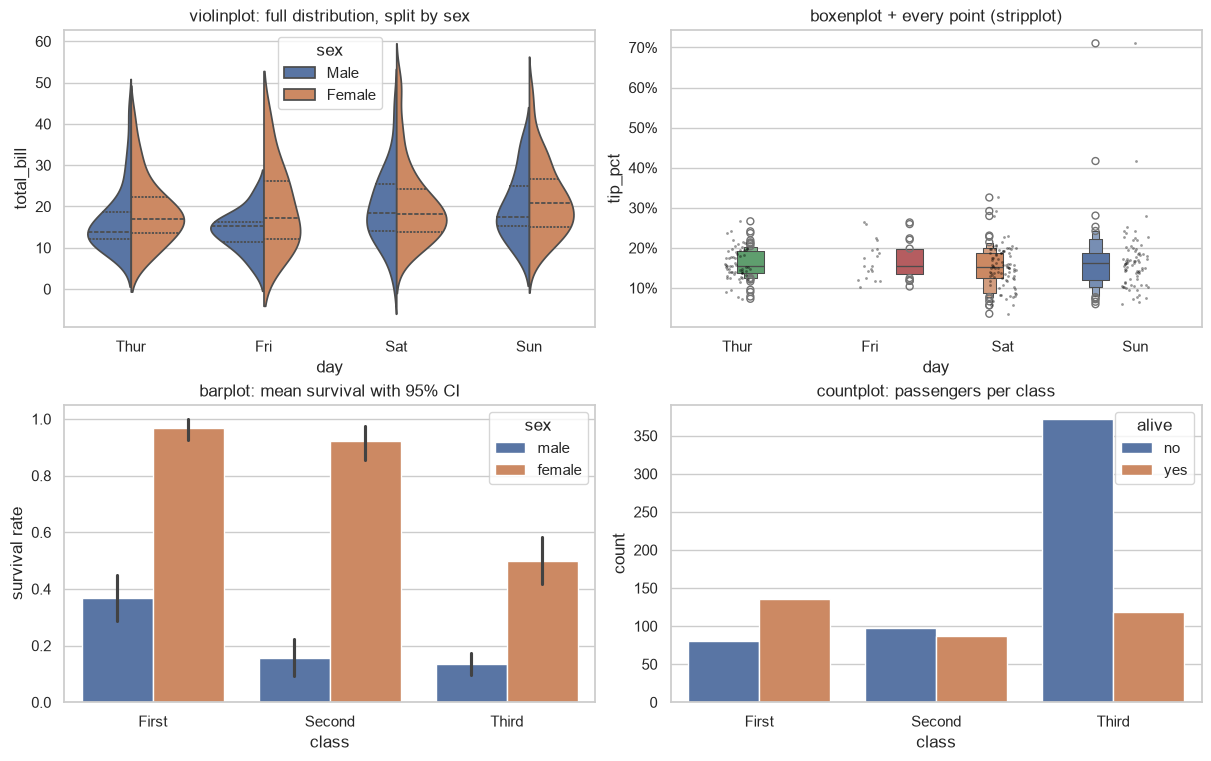

sex     female   male
class                
First    0.968  0.369
Second   0.921  0.157
Third    0.500  0.135
→ third-class women survived at 50%, more than first-class men (37%)


In [23]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7.5), layout="constrained")
sns.violinplot(data=tips, x="day", y="total_bill", hue="sex", split=True, inner="quart", ax=axes[0, 0])
axes[0, 0].set_title("violinplot: full distribution, split by sex")

sns.boxenplot(data=tips, x="day", y="tip_pct", hue="day", legend=False, ax=axes[0, 1])
sns.stripplot(data=tips, x="day", y="tip_pct", color="black", size=2, alpha=0.4, ax=axes[0, 1])
axes[0, 1].yaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=1))
axes[0, 1].set_title("boxenplot + every point (stripplot)")

sns.barplot(data=titanic, x="class", y="survived", hue="sex", errorbar=("ci", 95), seed=0, ax=axes[1, 0])
axes[1, 0].set(title="barplot: mean survival with 95% CI", ylabel="survival rate")

sns.countplot(data=titanic, x="class", hue="alive", ax=axes[1, 1])
axes[1, 1].set_title("countplot: passengers per class")
plt.show()

rates = titanic.groupby(["class", "sex"], observed=True)["survived"].mean().unstack()
print(rates.round(3))
print(f"→ third-class women survived at {rates.loc['Third', 'female']:.0%}, "
      f"{'more' if rates.loc['Third', 'female'] > rates.loc['First', 'male'] else 'less'} than first-class men ({rates.loc['First', 'male']:.0%})")

### Relationships

`lineplot` **aggregates** repeated x values: each point below is the mean of 12 months, with a bootstrapped 95% CI band. `scatterplot` maps extra variables to `hue`, `style`, and `size`.

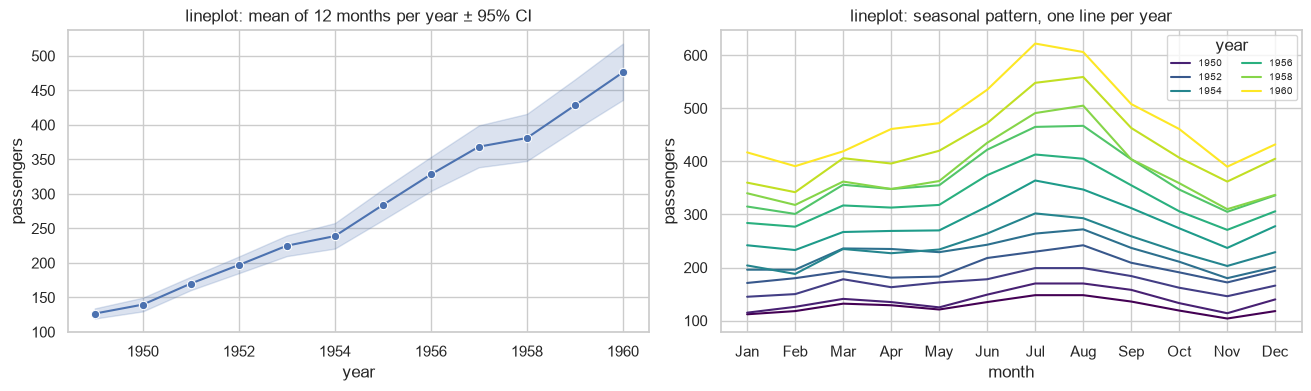

busiest months on average: Jul, Aug | quietest: Nov


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), layout="constrained")
sns.lineplot(data=flights, x="year", y="passengers", errorbar=("ci", 95), seed=0, marker="o", ax=axes[0])
axes[0].set_title("lineplot: mean of 12 months per year ± 95% CI")
sns.lineplot(data=flights, x="month", y="passengers", hue="year", palette="viridis", ax=axes[1])
axes[1].set_title("lineplot: seasonal pattern, one line per year")
axes[1].legend(ncols=2, fontsize=7, title="year")
plt.show()

busiest = flights.groupby("month", observed=True)["passengers"].mean().sort_values(ascending=False)
print(f"busiest months on average: {', '.join(busiest.index[:2].astype(str))} | quietest: {busiest.index[-1]}")

### ✍️ Your Turn

Draw `sns.barplot` of Titanic **survival rate by class** (no `hue`) on a new Axes, then store the bar heights (`[p.get_height() for p in ax.patches]`) in `bar_heights`. They should equal the group means.

In [25]:
bar_heights = None  # TODO
check("bar_heights", bar_heights, titanic.groupby("class", observed=True)["survived"].mean().to_numpy(),
      hint="fig, ax = plt.subplots(); sns.barplot(data=titanic, x='class', y='survived', ax=ax)")

⏳ bar_heights: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
fig, ax_bars = plt.subplots(figsize=(5, 3))
sns.barplot(data=titanic, x="class", y="survived", errorbar=("ci", 95), seed=0, ax=ax_bars)
bar_heights = [p.get_height() for p in ax_bars.patches]
plt.show()
check("bar_heights", bar_heights, titanic.groupby("class", observed=True)["survived"].mean().to_numpy())
```
The bar is the **mean**; the black line is a bootstrapped 95% CI of that mean — not the spread of individual passengers.
</details>

> 💡 **Interview angle:** "What do the error bars on a seaborn barplot mean?" — by default a 95% bootstrap **confidence interval of the mean** (`errorbar=("ci", 95)`); use `errorbar="sd"` for the spread of the data. Always say which one a chart shows.

## 11. Regression Plots, Heatmaps, and Correlation Matrices 🟡

`regplot` / `lmplot` fit a **linear regression line** with a 95% CI band — a visual check, not a modeling tool.

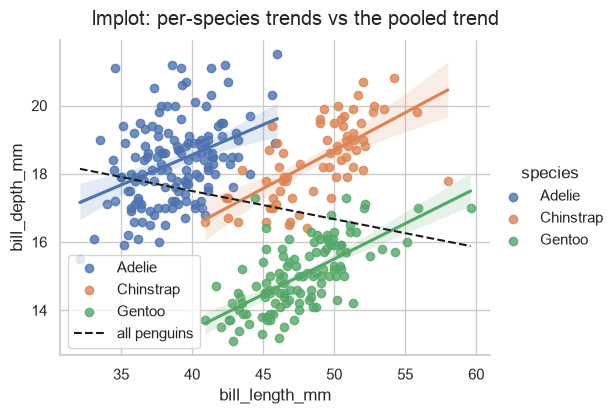

   Adelie: slope +0.177 mm depth per mm length
Chinstrap: slope +0.222 mm depth per mm length
   Gentoo: slope +0.208 mm depth per mm length
all penguins: slope -0.082 → the pooled trend has the opposite sign (Simpson’s paradox)


In [26]:
g = sns.lmplot(data=penguins, x="bill_length_mm", y="bill_depth_mm", hue="species", height=4, aspect=1.3)
overall = np.polyfit(penguins["bill_length_mm"], penguins["bill_depth_mm"], deg=1)
xs = np.linspace(penguins["bill_length_mm"].min(), penguins["bill_length_mm"].max(), 10)
g.ax.plot(xs, np.polyval(overall, xs), "k--", label="all penguins")
g.ax.legend()
g.figure.suptitle("lmplot: per-species trends vs the pooled trend", y=1.03)
plt.show()

for species, grp in penguins.groupby("species"):
    print(f"{species:>9}: slope {np.polyfit(grp['bill_length_mm'], grp['bill_depth_mm'], 1)[0]:+.3f} mm depth per mm length")
print(f"all penguins: slope {overall[0]:+.3f} → {'the pooled trend has the opposite sign (Simpson’s paradox)' if overall[0] < 0 else 'same sign as species trends'}")

**Heatmaps** show a matrix of values as colours. For a **correlation matrix**, use a **diverging** colormap with limits fixed at −1 and +1 (so 0 is the neutral middle colour), annotate the values, and mask the redundant upper triangle.

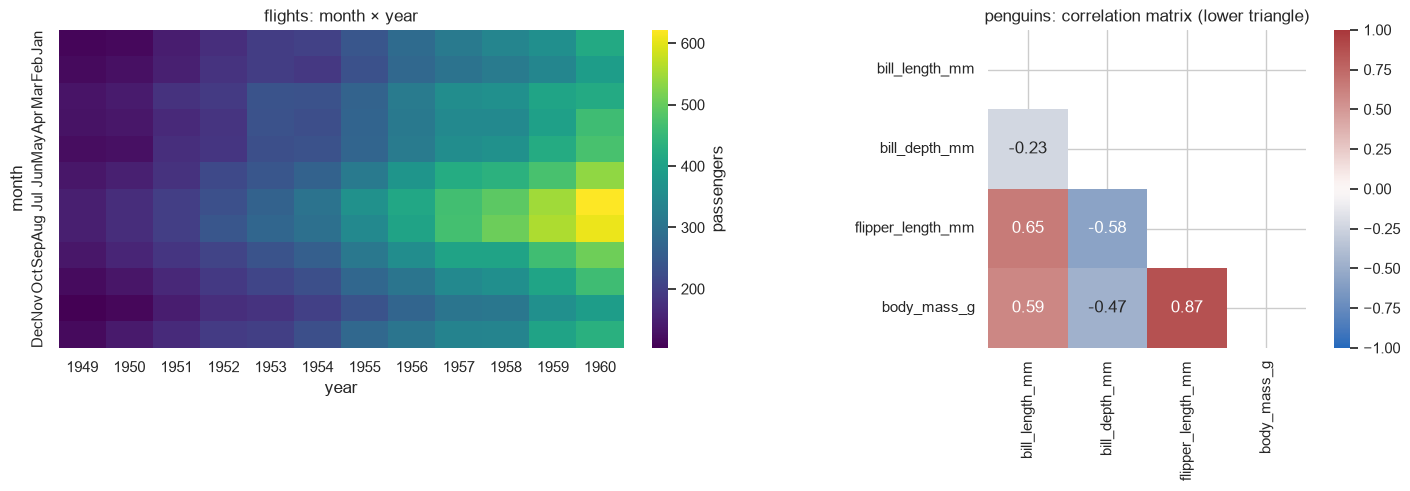

strongest correlation: flipper_length_mm ↔ body_mass_g (r = +0.87)


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), layout="constrained")
sns.heatmap(passengers_grid, cmap="viridis", cbar_kws={"label": "passengers"}, ax=axes[0])
axes[0].set_title("flights: month × year")

corr = penguins.select_dtypes("number").corr()
mask = np.triu(np.ones_like(corr, dtype=bool))                        # hide the diagonal and the mirror image
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="vlag", vmin=-1, vmax=1, square=True, ax=axes[1])
axes[1].set_title("penguins: correlation matrix (lower triangle)")
plt.show()

pairs = corr.where(~np.eye(len(corr), dtype=bool)).stack()
strongest = pairs.abs().idxmax()
print(f"strongest correlation: {strongest[0]} ↔ {strongest[1]} (r = {pairs[strongest]:+.2f})")

### ✍️ Your Turn

Using `corr`, find the pair of **different** variables with the largest **absolute** correlation. Store the two column names as a tuple in `strongest_pair`.

In [28]:
strongest_pair = None  # TODO
check("strongest_pair", None if strongest_pair is None else set(strongest_pair), {"flipper_length_mm", "body_mass_g"},
      hint="Blank the diagonal with corr.where(~np.eye(len(corr), dtype=bool)), then .abs().stack().idxmax()")

⏳ strongest_pair: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
off_diagonal = corr.where(~np.eye(len(corr), dtype=bool))
strongest_pair = off_diagonal.abs().stack().idxmax()
check("strongest_pair", set(strongest_pair), {"flipper_length_mm", "body_mass_g"})
```
Without blanking the diagonal you'd get a variable paired with itself (r = 1).
</details>

> 💡 **Interview angle:** "You see two features with r = 0.95 in the heatmap — what do you do?" — check for redundancy/multicollinearity (unstable linear-model coefficients, split importance in trees), consider dropping one or regularizing, and remember correlation heatmaps only show **linear, pairwise** relationships.

## 12. Multi-Plot Grids: pairplot, FacetGrid, jointplot 🟡

- `pairplot` — every numeric pair as a scatter, distributions on the diagonal. Great first look at a new dataset.
- `FacetGrid` — the engine behind figure-level functions: split data into `row` × `col` panels and map any plotting function.
- `jointplot` — one relationship plus both marginal distributions.

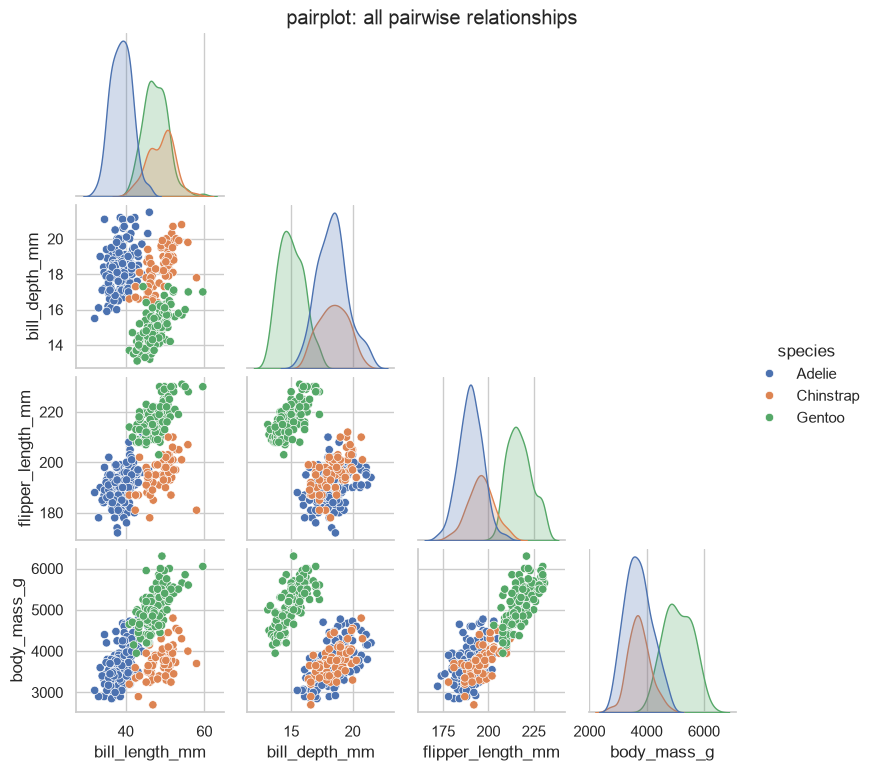

In [29]:
g = sns.pairplot(penguins, hue="species", corner=True, height=1.9,
                 vars=["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"])
g.figure.suptitle("pairplot: all pairwise relationships", y=1.01)
plt.show()

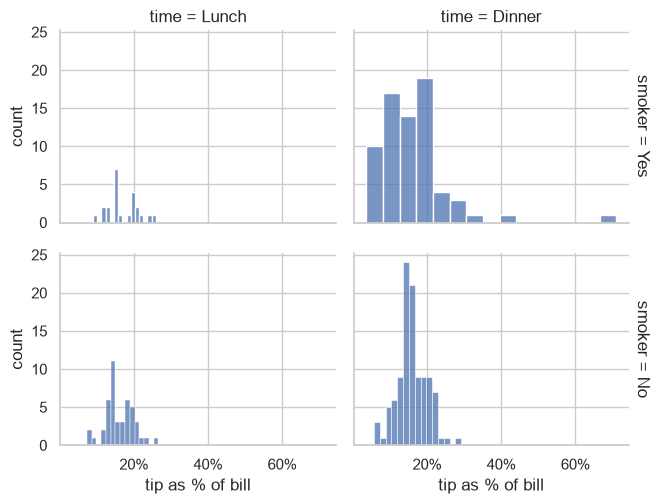

               median  size
smoker time                
Yes    Lunch    0.154    23
       Dinner   0.149    70
No     Lunch    0.153    45
       Dinner   0.156   106


In [30]:
g = sns.FacetGrid(tips, row="smoker", col="time", height=2.6, aspect=1.3, margin_titles=True)
g.map_dataframe(sns.histplot, x="tip_pct", bins=15)
g.set_axis_labels("tip as % of bill", "count")
for ax in g.axes.flat:
    ax.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=1))
plt.show()
print(tips.groupby(["smoker", "time"], observed=True)["tip_pct"].agg(["median", "size"]).round(3))

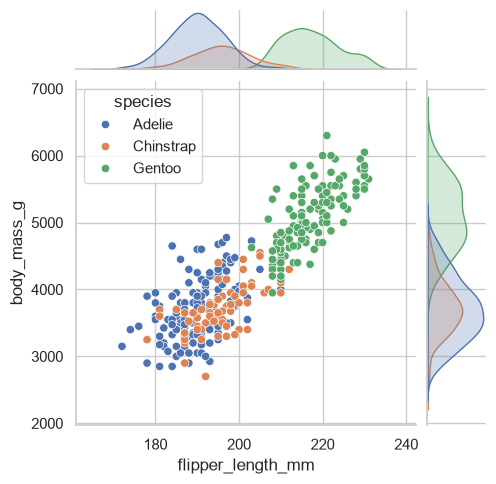

In [31]:
g = sns.jointplot(data=penguins, x="flipper_length_mm", y="body_mass_g", hue="species", height=5)
plt.show()

> 💡 **Interview angle:** "How do you start EDA on a new tabular dataset?" — shape/dtypes/missingness table, target distribution, a `pairplot` (or a sample of it) coloured by the target, correlation heatmap, then small multiples of key features by the target — while writing down every observation *with the number that supports it*.

## 13. Plots Every ML Engineer Makes 🔴

These diagnostics come up in almost every ML interview and code review. We fit models on **training data only** and evaluate on a held-out **test set**.

| Plot | Answers |
|---|---|
| Learning curves | more data, or a different model? (bias vs variance) |
| Confusion matrix | *which* mistakes does the classifier make? |
| ROC / precision–recall curves | how good is the ranking at every threshold? |
| Residual plots | what does a regression model systematically miss? |
| Feature importance | which inputs drive predictions? |
| 2-D embedding scatter | is there visible structure between classes? |

In [32]:
from sklearn.datasets import load_breast_cancer, load_diabetes, load_digits
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (PrecisionRecallDisplay, PredictionErrorDisplay, RocCurveDisplay, average_precision_score,
                             confusion_matrix, precision_score, r2_score, recall_score, roc_auc_score)
from sklearn.model_selection import learning_curve, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

cancer = load_breast_cancer(as_frame=True)
X_cancer = cancer.data
y_cancer = (cancer.target == 0).astype(int)                 # 1 = malignant: the class we most want to catch
X_train, X_test, y_train, y_test = train_test_split(X_cancer, y_cancer, test_size=0.25, stratify=y_cancer, random_state=0)
print(f"train {X_train.shape}, test {X_test.shape}, malignant share in test = {y_test.mean():.1%}")

train (426, 30), test (143, 30), malignant share in test = 37.1%


### 13a. Learning curves — bias or variance?

Train on growing subsets and score on cross-validation folds (inside the training set). **High variance (overfitting):** training score ≫ validation score, and the gap shrinks slowly as data grows → more data or regularization helps. **High bias (underfitting):** both scores are low and close → a more flexible model or better features helps.

logistic regression              final train 0.992 | validation 0.981 | gap +0.011 → good fit — small gap, high validation score


decision tree (no depth limit)   final train 1.000 | validation 0.925 | gap +0.075 → high variance — large train/validation gap


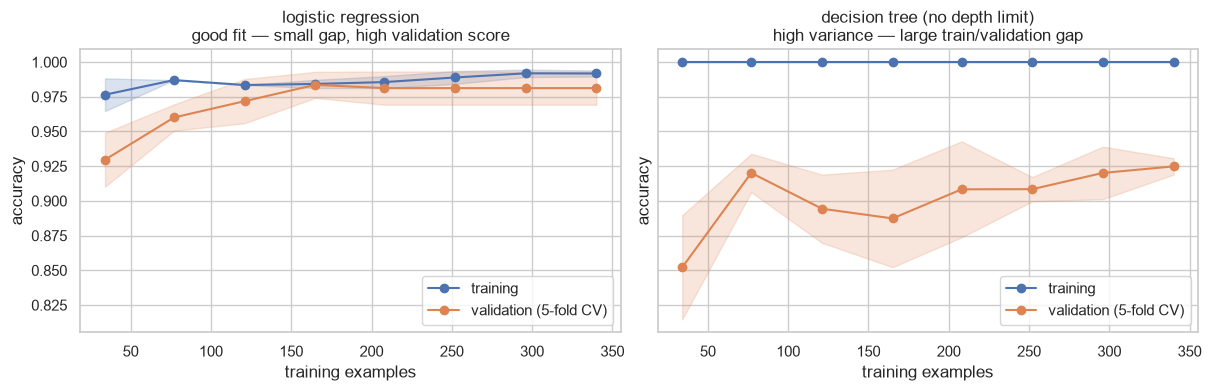

In [33]:
curve_models = {
    "logistic regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    "decision tree (no depth limit)": DecisionTreeClassifier(random_state=0),
}
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True, layout="constrained")
for ax, (name, model) in zip(axes, curve_models.items()):
    sizes, train_scores, val_scores = learning_curve(model, X_train, y_train, cv=5, scoring="accuracy",
                                                     train_sizes=np.linspace(0.1, 1.0, 8))
    for scores, label, color in [(train_scores, "training", "C0"), (val_scores, "validation (5-fold CV)", "C1")]:
        mean, std = scores.mean(axis=1), scores.std(axis=1)
        ax.plot(sizes, mean, marker="o", color=color, label=label)
        ax.fill_between(sizes, mean - std, mean + std, color=color, alpha=0.2)
    gap = train_scores.mean(axis=1)[-1] - val_scores.mean(axis=1)[-1]
    val_final = val_scores.mean(axis=1)[-1]
    if gap > 0.03:
        diagnosis = "high variance — large train/validation gap"
    elif val_final < 0.90:
        diagnosis = "high bias — both scores low"
    else:
        diagnosis = "good fit — small gap, high validation score"
    ax.set(title=f"{name}\n{diagnosis}", xlabel="training examples", ylabel="accuracy")
    ax.legend(loc="lower right")
    print(f"{name:<32} final train {train_scores.mean(axis=1)[-1]:.3f} | validation {val_final:.3f} | gap {gap:+.3f} → {diagnosis}")
plt.show()

### 13b. Confusion matrix

Rows = **true** class, columns = **predicted** class. Showing counts *and* row percentages makes recall per class visible at a glance.

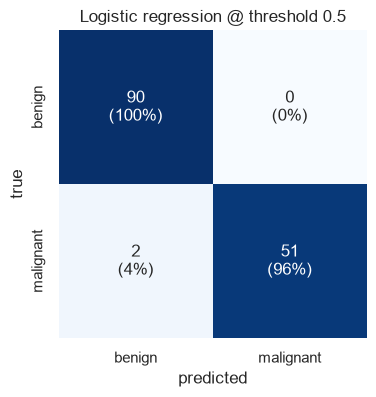

TP=51 FP=0 FN=2 TN=90 | precision = 1.000 | recall = 0.962 → 2 malignant tumour(s) missed, 0 false alarm(s)


In [34]:
clf_models = {
    "logistic regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    "random forest": RandomForestClassifier(n_estimators=300, random_state=0),
}
proba = {name: model.fit(X_train, y_train).predict_proba(X_test)[:, 1] for name, model in clf_models.items()}

y_pred = (proba["logistic regression"] >= 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)                         # [[TN, FP], [FN, TP]] with 1 = malignant
cm_row = cm / cm.sum(axis=1, keepdims=True)
annotations = np.array([[f"{count}\n({share:.0%})" for count, share in zip(r_counts, r_shares)] for r_counts, r_shares in zip(cm, cm_row)])

fig, ax = plt.subplots(figsize=(4.8, 4))
sns.heatmap(cm_row, annot=annotations, fmt="", cmap="Blues", vmin=0, vmax=1, cbar=False, square=True,
            xticklabels=["benign", "malignant"], yticklabels=["benign", "malignant"], ax=ax)
ax.set(xlabel="predicted", ylabel="true", title="Logistic regression @ threshold 0.5")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"TP={tp} FP={fp} FN={fn} TN={tn} | precision = {tp / (tp + fp):.3f} | recall = {tp / (tp + fn):.3f} "
      f"→ {fn} malignant tumour(s) missed, {fp} false alarm(s)")

### ✍️ Your Turn

From the confusion matrix `cm` above, compute **precision** and **recall** for the malignant class yourself. Store them in `precision_turn` and `recall_turn`.

In [35]:
precision_turn = None  # TODO: TP / (TP + FP)
recall_turn = None     # TODO: TP / (TP + FN)
check("precision", precision_turn, precision_score(y_test, y_pred), hint="cm.ravel() gives tn, fp, fn, tp in that order.")
check("recall", recall_turn, recall_score(y_test, y_pred), hint="Recall divides by all truly malignant cases: TP + FN.")

⏳ precision: not attempted yet — replace None with your answer.
⏳ recall: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
tn_, fp_, fn_, tp_ = cm.ravel()
precision_turn = tp_ / (tp_ + fp_)
recall_turn = tp_ / (tp_ + fn_)
check("precision", precision_turn, precision_score(y_test, y_pred))
check("recall", recall_turn, recall_score(y_test, y_pred))
```
</details>

### 13c. ROC and precision–recall curves

Both sweep the decision threshold from high to low.

- **ROC:** true-positive rate (recall) vs false-positive rate. Random guessing = the diagonal; **AUC** = probability a random positive is scored above a random negative.
- **Precision–recall:** precision vs recall. Random guessing = a flat line at the **positive-class prevalence**. More informative when positives are rare, because ROC's false-positive rate is diluted by the many negatives.

logistic regression  ROC AUC = 0.9958 | average precision = 0.9940
random forest        ROC AUC = 0.9873 | average precision = 0.9874


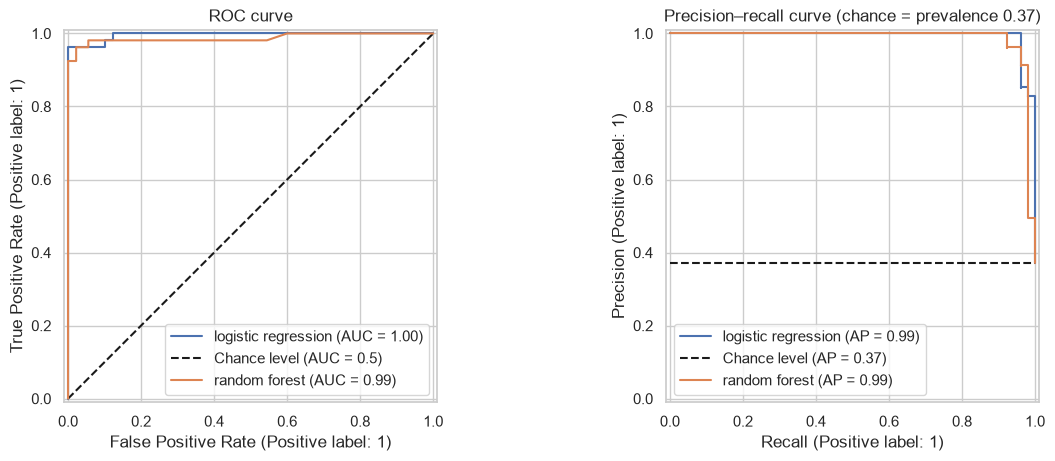

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), layout="constrained")
for i, (name, scores) in enumerate(proba.items()):
    RocCurveDisplay.from_predictions(y_test, scores, name=name, ax=axes[0], plot_chance_level=(i == 0))
    PrecisionRecallDisplay.from_predictions(y_test, scores, name=name, ax=axes[1], plot_chance_level=(i == 0))
    print(f"{name:<20} ROC AUC = {roc_auc_score(y_test, scores):.4f} | average precision = {average_precision_score(y_test, scores):.4f}")
axes[0].set_title("ROC curve")
axes[1].set_title(f"Precision–recall curve (chance = prevalence {y_test.mean():.2f})")
plt.show()

### 13d. Residual plots (regression)

A good regression leaves residuals (actual − predicted) that look like **structureless noise around 0**. Curves suggest a missing non-linear feature; a funnel (spread growing with the prediction) suggests heteroscedasticity — consider a log target or a different loss.

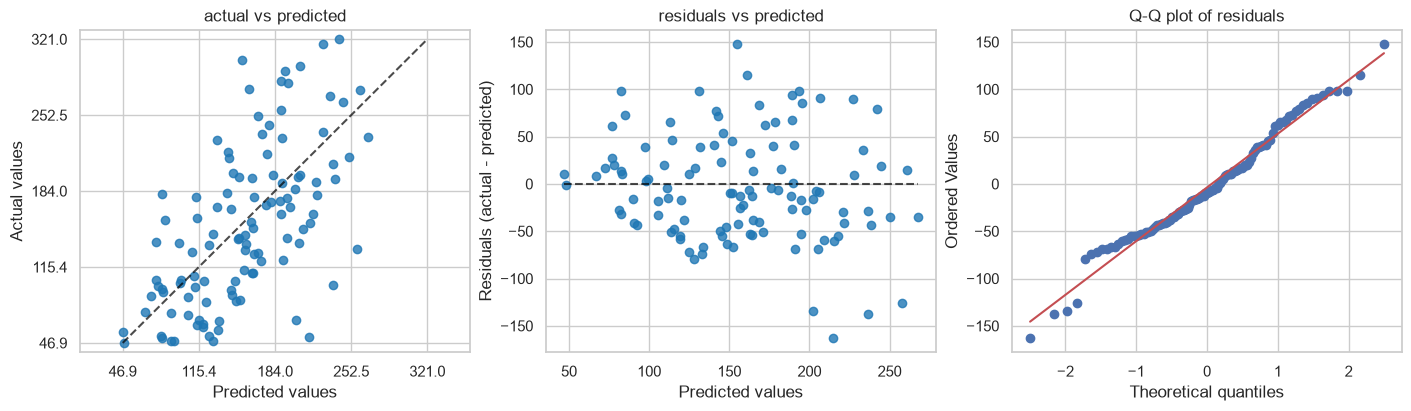

test R² = 0.359 | mean residual = -3.72
Spearman(prediction, |residual|) = +0.20 (p = 0.038) → spread grows with the prediction (funnel)


In [37]:
X_dia, y_dia = load_diabetes(return_X_y=True, as_frame=True)
Xd_train, Xd_test, yd_train, yd_test = train_test_split(X_dia, y_dia, test_size=0.25, random_state=0)
regressor = LinearRegression().fit(Xd_train, yd_train)
yd_pred = regressor.predict(Xd_test)
residuals = yd_test - yd_pred

fig, axes = plt.subplots(1, 3, figsize=(14, 4), layout="constrained")
PredictionErrorDisplay.from_predictions(yd_test, yd_pred, kind="actual_vs_predicted", ax=axes[0])
axes[0].set_title("actual vs predicted")
PredictionErrorDisplay.from_predictions(yd_test, yd_pred, kind="residual_vs_predicted", ax=axes[1])
axes[1].set_title("residuals vs predicted")
stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q plot of residuals")
plt.show()

spread_trend = stats.spearmanr(yd_pred, np.abs(residuals))
print(f"test R² = {r2_score(yd_test, yd_pred):.3f} | mean residual = {residuals.mean():+.2f}")
print(f"Spearman(prediction, |residual|) = {spread_trend.statistic:+.2f} (p = {spread_trend.pvalue:.3f}) → "
      f"{'spread grows with the prediction (funnel)' if spread_trend.pvalue < 0.05 and spread_trend.statistic > 0 else 'no clear evidence of a funnel'}")

### 13e. Feature importance

**Impurity-based** importance (built into tree ensembles) is computed on training data and is biased toward high-cardinality features. **Permutation importance** shuffles one feature at a time on **held-out data** and measures how much the score drops — model-agnostic and more trustworthy, though correlated features share (and can hide) importance.

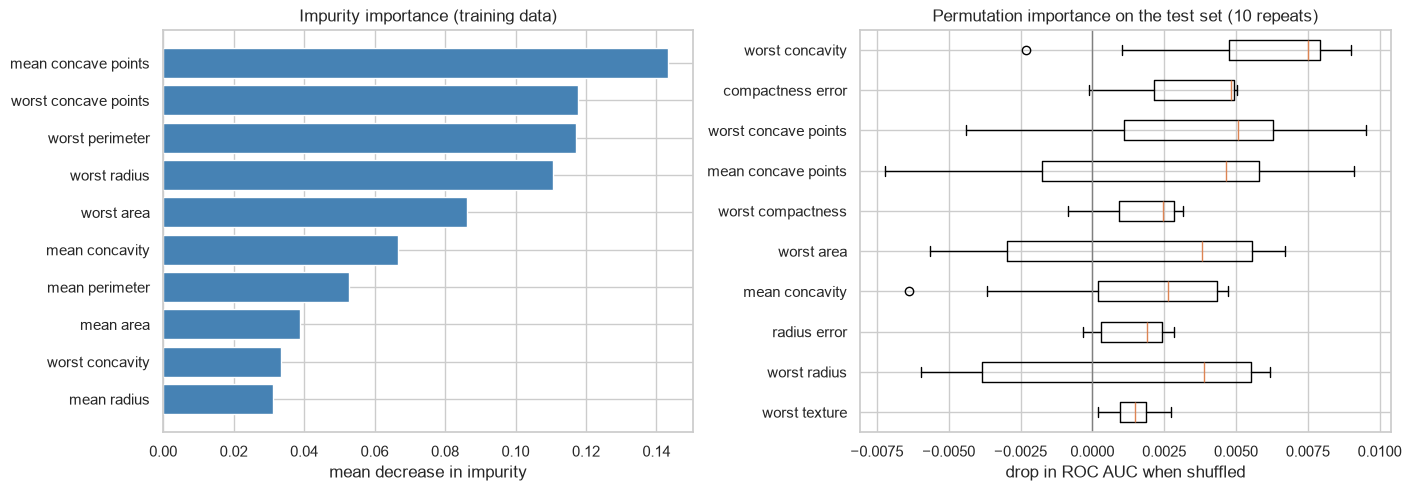

top-5 features agree on 2 of 5: ['mean concave points', 'worst concave points']
largest single permutation drop in AUC: 0.0057 | 10% of feature pairs have |r| > 0.8, so a shuffled feature can have a correlated stand-in that keeps the score up


In [38]:
forest = clf_models["random forest"]
impurity = pd.Series(forest.feature_importances_, index=X_cancer.columns).sort_values()
perm = permutation_importance(forest, X_test, y_test, n_repeats=10, random_state=0, scoring="roc_auc")
top_perm = np.argsort(perm.importances_mean)[-10:]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), layout="constrained")
axes[0].barh(impurity.index[-10:], impurity.values[-10:], color="steelblue")
axes[0].set(title="Impurity importance (training data)", xlabel="mean decrease in impurity")
axes[1].boxplot(perm.importances[top_perm].T, tick_labels=X_cancer.columns[top_perm], orientation="horizontal")
axes[1].axvline(0, color="gray", lw=1)
axes[1].set(title="Permutation importance on the test set (10 repeats)", xlabel="drop in ROC AUC when shuffled")
plt.show()

top5_impurity = set(impurity.index[-5:])
top5_perm = set(X_cancer.columns[np.argsort(perm.importances_mean)[-5:]])
print(f"top-5 features agree on {len(top5_impurity & top5_perm)} of 5: {sorted(top5_impurity & top5_perm)}")
feature_pair_corr = np.abs(X_cancer.corr().to_numpy()[np.triu_indices(X_cancer.shape[1], k=1)])
print(f"largest single permutation drop in AUC: {perm.importances_mean.max():.4f} | "
      f"{(feature_pair_corr > 0.8).mean():.0%} of feature pairs have |r| > 0.8, so a shuffled feature can have a correlated stand-in that keeps the score up")

### 13f. 2-D embedding scatter (PCA)

Project high-dimensional data to 2-D to look for structure. **PCA** finds the directions of largest variance *after centering the data*; the axis labels should say how much variance each component keeps. (t-SNE and UMAP show clusters more vividly, but their distances and cluster sizes are not reliable.) This is a visualization of all 1,797 digits — no model is evaluated, so there is no test set to protect.

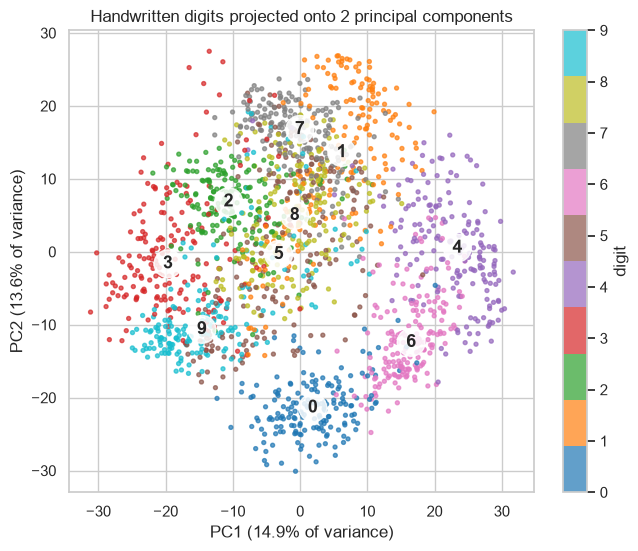

2 components keep 28.5% of the variance | closest class centres in this view: 5 and 8 → expect overlap there


In [39]:
digits = load_digits()
pca = PCA(n_components=2, random_state=0)
embedding = pca.fit_transform(digits.data)
evr = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(7.5, 6))
points = ax.scatter(embedding[:, 0], embedding[:, 1], c=digits.target, cmap="tab10", s=8, alpha=0.7)
centroids = np.array([np.median(embedding[digits.target == d], axis=0) for d in range(10)])
for d, (cx, cy) in enumerate(centroids):
    ax.text(cx, cy, str(d), fontsize=13, weight="bold", ha="center", va="center", bbox={"boxstyle": "circle", "fc": "white", "alpha": 0.85})
ax.set(xlabel=f"PC1 ({evr[0]:.1%} of variance)", ylabel=f"PC2 ({evr[1]:.1%} of variance)",
       title="Handwritten digits projected onto 2 principal components")
fig.colorbar(points, ax=ax, ticks=range(10), label="digit")
plt.show()

dist = np.linalg.norm(centroids[:, None, :] - centroids[None, :, :], axis=-1)
np.fill_diagonal(dist, np.inf)
i, j = np.unravel_index(dist.argmin(), dist.shape)
print(f"2 components keep {evr.sum():.1%} of the variance | closest class centres in this view: {i} and {j} → expect overlap there")

> 💡 **Interview angle:** "ROC AUC is 0.95 but the fraud team says the model is useless — how?" — with rare positives, a low false-positive *rate* can still mean many more false alarms than true frauds; show the **precision–recall curve** (baseline = prevalence) and pick a threshold from business costs.

## 🔧 Build It From Scratch

Two plots that look like magic are just a few lines of NumPy. We rebuild both and **assert** they match NumPy, Matplotlib, Seaborn, and SciPy.

### 1) A histogram: bin, count, draw bars

1. Split `[min, max]` into `bins` equal-width intervals → `bins + 1` edges.
2. Each value's bin = (number of edges ≤ value) − 1; the maximum value goes in the **last** bin (the last interval includes its right edge).
3. Count values per bin and draw one bar per bin.

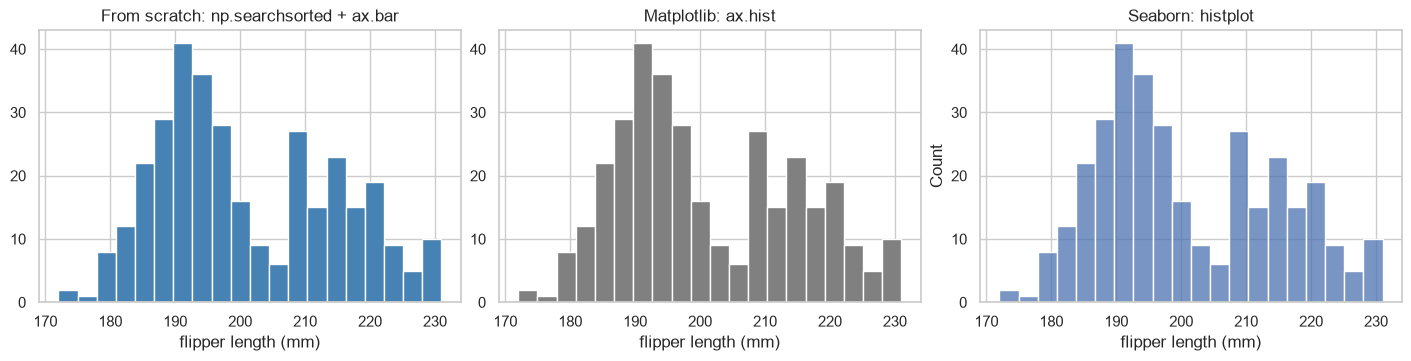

counts and edges match NumPy, Matplotlib and Seaborn exactly ✅  (counts: [2, 1, 8, 12, 22, 29, 41, 36, 28, 16, 9, 6, 27, 15, 23, 15, 19, 9, 5, 10])


In [40]:
def histogram_from_scratch(x, bins):
    x = np.asarray(x, dtype=float)
    edges = np.linspace(x.min(), x.max(), bins + 1)
    bin_index = np.searchsorted(edges, x, side="right") - 1          # how many edges are ≤ x, minus 1
    bin_index = np.clip(bin_index, 0, bins - 1)                       # x == max belongs to the last bin
    counts = np.bincount(bin_index, minlength=bins)
    return counts, edges


flipper = penguins["flipper_length_mm"].to_numpy()
our_counts, our_edges = histogram_from_scratch(flipper, bins=20)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), layout="constrained")
axes[0].bar(our_edges[:-1], our_counts, width=np.diff(our_edges), align="edge", color="steelblue", edgecolor="white")
axes[0].set(title="From scratch: np.searchsorted + ax.bar", xlabel="flipper length (mm)")
mpl_counts, mpl_edges, _ = axes[1].hist(flipper, bins=20, color="gray", edgecolor="white")
axes[1].set(title="Matplotlib: ax.hist", xlabel="flipper length (mm)")
sns.histplot(x=flipper, bins=20, ax=axes[2])
axes[2].set(title="Seaborn: histplot", xlabel="flipper length (mm)")
plt.show()

np_counts, np_edges = np.histogram(flipper, bins=20)
sns_heights = np.array([patch.get_height() for patch in axes[2].patches])
sns_lefts = np.array([patch.get_x() for patch in axes[2].patches])
assert np.array_equal(our_counts, np_counts) and np.allclose(our_edges, np_edges)
assert np.array_equal(our_counts, mpl_counts) and np.allclose(our_edges, mpl_edges)
assert np.array_equal(our_counts, sns_heights) and np.allclose(our_edges[:-1], sns_lefts)
print(f"counts and edges match NumPy, Matplotlib and Seaborn exactly ✅  (counts: {our_counts.tolist()})")

### 2) A Gaussian kernel density estimate

Put a small bell curve (a **Gaussian kernel**) with width *h* on every data point and average them:

$$\hat f(x) = \frac{1}{n}\sum_{i=1}^{n} \frac{1}{h\sqrt{2\pi}}\, e^{-\frac{1}{2}\left(\frac{x - x_i}{h}\right)^2}$$

The width *h* (**bandwidth**) controls smoothness. SciPy and Seaborn default to **Scott's rule**: $h = s \cdot n^{-1/5}$ in 1-D, where *s* is the sample standard deviation. Seaborn evaluates the curve on 200 points from `min − 3h` to `max + 3h`.

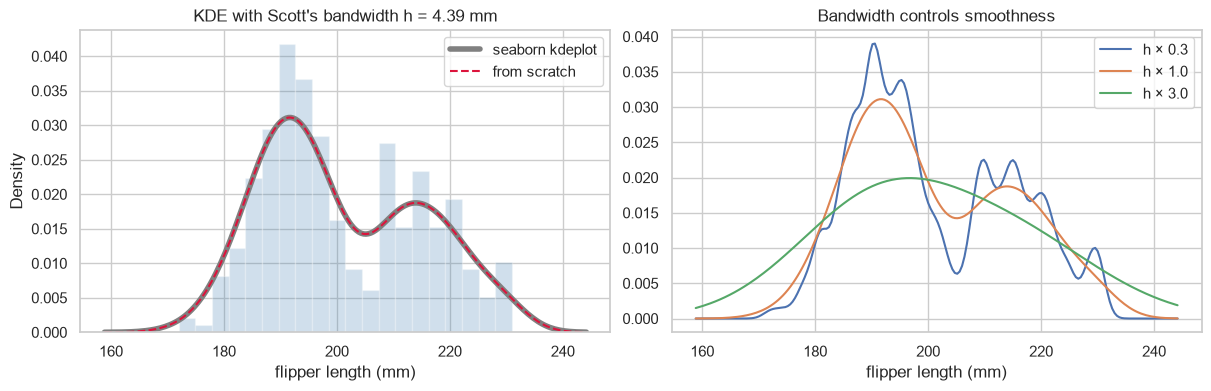

bandwidth matches SciPy; density matches scipy.stats.gaussian_kde and seaborn.kdeplot ✅ (max abs difference vs seaborn: 9.4e-17)
area under our curve ≈ 1.0000 (a density integrates to 1)


In [41]:
def kde_from_scratch(data, grid, bw_adjust=1.0):
    data = np.asarray(data, dtype=float)
    h = data.std(ddof=1) * len(data) ** (-1 / 5) * bw_adjust          # Scott's rule × optional adjustment
    z = (grid[:, None] - data[None, :]) / h                           # shape (grid points, data points)
    kernels = np.exp(-0.5 * z ** 2) / (h * np.sqrt(2 * np.pi))
    return kernels.mean(axis=1), h


h = flipper.std(ddof=1) * len(flipper) ** (-1 / 5)
grid = np.linspace(flipper.min() - 3 * h, flipper.max() + 3 * h, 200)
our_density, our_h = kde_from_scratch(flipper, grid)

scipy_kde = stats.gaussian_kde(flipper)                               # bw_method="scott" by default
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), layout="constrained")
sns.kdeplot(x=flipper, ax=axes[0], color="gray", lw=4, label="seaborn kdeplot")
axes[0].plot(grid, our_density, color="crimson", ls="--", label="from scratch")
axes[0].hist(flipper, bins=20, density=True, alpha=0.25, color="steelblue")
axes[0].set(title=f"KDE with Scott's bandwidth h = {our_h:.2f} mm", xlabel="flipper length (mm)")
axes[0].legend()
for adjust in (0.3, 1.0, 3.0):
    axes[1].plot(grid, kde_from_scratch(flipper, grid, bw_adjust=adjust)[0], label=f"h × {adjust}")
axes[1].set(title="Bandwidth controls smoothness", xlabel="flipper length (mm)")
axes[1].legend()
plt.show()

seaborn_xy = axes[0].lines[0].get_xydata()
assert np.isclose(our_h, np.sqrt(scipy_kde.covariance[0, 0]))
assert np.allclose(our_density, scipy_kde(grid), rtol=1e-10)
assert np.allclose(seaborn_xy[:, 0], grid) and np.allclose(seaborn_xy[:, 1], our_density, rtol=1e-10)
print(f"bandwidth matches SciPy; density matches scipy.stats.gaussian_kde and seaborn.kdeplot ✅ "
      f"(max abs difference vs seaborn: {np.abs(seaborn_xy[:, 1] - our_density).max():.1e})")
print(f"area under our curve ≈ {np.trapezoid(our_density, grid):.4f} (a density integrates to 1)")

Notice the small bumps at `h × 0.3` (too wiggly — every cluster of values becomes a peak) and the lost bimodality at `h × 3` (too smooth). The two flipper-length humps are real: they're different species.

## ⚠️ Common Pitfalls

### ❌ Pitfall 1 — Passing `transform=` to `axhline`

❌ ValueError: 'transform' is not allowed as a keyword argument; axhline generates its own transform.


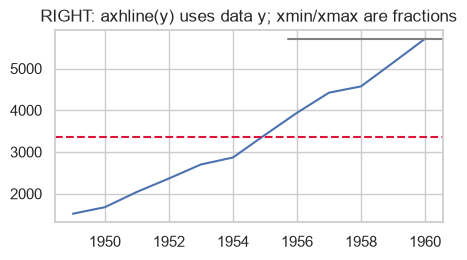

In [42]:
fig, ax = plt.subplots(figsize=(5, 2.5))
ax.plot(yearly.index, yearly.values)
try:
    ax.axhline(0.5, transform=ax.transAxes)                            # ❌ axhline builds its own transform
except (TypeError, ValueError) as err:
    print(f"❌ {type(err).__name__}: {err}")

ax.axhline(yearly.mean(), color="crimson", ls="--")                     # ✅ y in DATA units, spans the full width
ax.axhline(yearly.max(), xmin=0.6, xmax=1.0, color="gray")              # ✅ xmin/xmax are Axes fractions
ax.set_title("RIGHT: axhline(y) uses data y; xmin/xmax are fractions")
plt.show()

### ❌ Pitfall 2 — Applying a style context *after* creating the Axes

In [43]:
fig, ax_before = plt.subplots(figsize=(4, 2.5))                         # ❌ created before the context
with plt.style.context("ggplot"):
    ax_before.plot(yearly.index, yearly.values)
    fig_inside, ax_inside = plt.subplots(figsize=(4, 2.5))             # ✅ created inside the context
    ax_inside.plot(yearly.index, yearly.values)
print(f"❌ Axes created before the context: background {mpl.colors.to_hex(ax_before.get_facecolor())} (style not applied)")
print(f"✅ Axes created inside the context: background {mpl.colors.to_hex(ax_inside.get_facecolor())}")
plt.close("all")

❌ Axes created before the context: background #ffffff (style not applied)
✅ Axes created inside the context: background #e5e5e5


### ❌ Pitfall 3 — `pd.cut` silently drops values equal to the first edge

In [44]:
adults = titanic[titanic["age"] >= 18]
groups_bad = pd.cut(adults["age"], bins=[18, 30, 50, 80])                              # intervals are (18, 30], …
groups_good = pd.cut(adults["age"], bins=[18, 30, 50, 80], include_lowest=True)        # first interval becomes [18, 30]
print(f"passengers aged exactly 18: {(adults['age'] == 18).sum()}")
print(f"❌ without include_lowest → {groups_bad.isna().sum()} adults fall into NO group (NaN) and vanish from every plot")
print(f"✅ with include_lowest=True → {groups_good.isna().sum()} missing")

passengers aged exactly 18: 26
❌ without include_lowest → 26 adults fall into NO group (NaN) and vanish from every plot
✅ with include_lowest=True → 0 missing


### ❌ Pitfall 4 — Writing the "insight" before looking at the data

In [45]:
fare_quartile = pd.qcut(titanic["fare"], 4, labels=["Q1 cheapest", "Q2", "Q3", "Q4 priciest"])
survival_by_fare = titanic.groupby(fare_quartile, observed=True)["survived"].mean()

claim = "Passengers who paid higher fares were LESS likely to survive."           # ❌ hard-coded text
print("❌", claim, "| contradicted by the data:", bool(survival_by_fare.iloc[-1] > survival_by_fare.iloc[0]))

direction = "MORE" if survival_by_fare.iloc[-1] > survival_by_fare.iloc[0] else "LESS"   # ✅ computed
print(f"✅ Passengers in the priciest fare quartile were {direction} likely to survive: "
      f"{survival_by_fare.iloc[-1]:.0%} vs {survival_by_fare.iloc[0]:.0%} in the cheapest quartile.")

❌ Passengers who paid higher fares were LESS likely to survive. | contradicted by the data: True
✅ Passengers in the priciest fare quartile were MORE likely to survive: 58% vs 20% in the cheapest quartile.


### ❌ Pitfall 5 — Seaborn `palette` without `hue` (deprecated)

❌ FutureWarning — Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set ` …


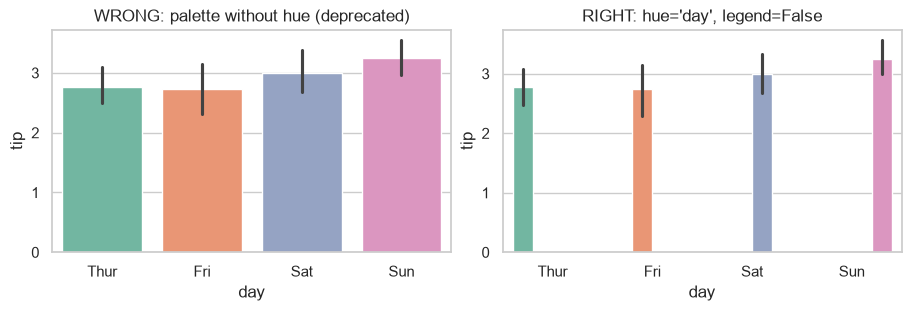

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3), layout="constrained")
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    sns.barplot(data=tips, x="day", y="tip", palette="Set2", ax=axes[0])      # ❌
print("❌", caught[0].category.__name__, "—", " ".join(str(caught[0].message).split())[:130], "…")

sns.barplot(data=tips, x="day", y="tip", hue="day", palette="Set2", legend=False, ax=axes[1])   # ✅
axes[0].set_title("WRONG: palette without hue (deprecated)")
axes[1].set_title("RIGHT: hue='day', legend=False")
plt.show()

### ❌ Pitfall 6 — Outdated Matplotlib arguments from old tutorials

❌ TypeError: Axes.boxplot() got an unexpected keyword argument 'labels'


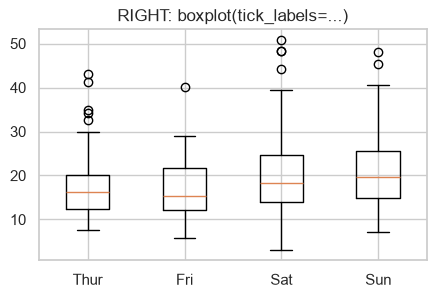

✅ Also current: mpl.colormaps['viridis'] (not cm.get_cmap), g.figure on seaborn grids, layout='constrained'.


In [47]:
fig, ax = plt.subplots(figsize=(5, 3))
bills_by_day = [tips.loc[tips["day"] == d, "total_bill"] for d in days]
try:
    ax.boxplot(bills_by_day, labels=days)                                   # ❌ renamed in Matplotlib 3.9, removed in 3.11
except TypeError as err:
    print(f"❌ TypeError: {err}")
ax.boxplot(bills_by_day, tick_labels=days)                                  # ✅
ax.set_title("RIGHT: boxplot(tick_labels=...)")
plt.show()
print("✅ Also current: mpl.colormaps['viridis'] (not cm.get_cmap), g.figure on seaborn grids, layout='constrained'.")

## 🏋️ Practice Exercises

Try each one before opening the solution. Run the cell: ⏳ means not attempted, ✅ means correct.

### 🟢 Exercise 1 — Yearly trend line
Compute `yearly_total` (total passengers per year from `flights`) and plot it as a line with markers on `ax_ex1`, titled **"Total airline passengers per year"**.

In [48]:
yearly_total = None  # TODO
ax_ex1 = None        # TODO
check("ex1 line data", None if ax_ex1 is None or not ax_ex1.lines else ax_ex1.lines[0].get_ydata(),
      flights.groupby("year")["passengers"].sum().to_numpy(), hint="flights.groupby('year')['passengers'].sum(), then ax_ex1.plot(...)")
check("ex1 title", None if ax_ex1 is None else ax_ex1.get_title(), "Total airline passengers per year")

⏳ ex1 line data: not attempted yet — replace None with your answer.
⏳ ex1 title: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
yearly_total = flights.groupby("year")["passengers"].sum()
fig, ax_ex1 = plt.subplots(figsize=(6, 3))
ax_ex1.plot(yearly_total.index, yearly_total.values, marker="o")
ax_ex1.set(title="Total airline passengers per year", xlabel="year", ylabel="passengers")
plt.show()
check("ex1 line data", ax_ex1.lines[0].get_ydata(), flights.groupby("year")["passengers"].sum().to_numpy())
check("ex1 title", ax_ex1.get_title(), "Total airline passengers per year")
```
</details>

### 🟢 Exercise 2 — Histogram counts
Draw a histogram of `penguins["body_mass_g"]` with **15 bins** using `ax.hist`, and keep the counts it returns in `counts_ex2`.

In [49]:
counts_ex2 = None  # TODO
check("counts_ex2", counts_ex2, np.histogram(penguins["body_mass_g"], bins=15)[0],
      hint="n, bin_edges, patches = ax.hist(data, bins=15) — the first return value is the counts.")

⏳ counts_ex2: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
fig, ax_ex2 = plt.subplots(figsize=(6, 3))
counts_ex2, edges_ex2, _ = ax_ex2.hist(penguins["body_mass_g"], bins=15, edgecolor="white")
ax_ex2.set(xlabel="body mass (g)", ylabel="count")
plt.show()
check("counts_ex2", counts_ex2, np.histogram(penguins["body_mass_g"], bins=15)[0])
```
</details>

### 🟢 Exercise 3 — Percent labels on bars
Bar-chart Titanic survival rate by sex and label each bar as a percentage with one decimal (e.g. `"74.2%"`). Store the label texts in `labels_ex3`.

In [50]:
labels_ex3 = None  # TODO
check("labels_ex3", labels_ex3, ["74.2%", "18.9%"], hint="texts = ax.bar_label(bars, fmt='{:.1%}'); [t.get_text() for t in texts]")

⏳ labels_ex3: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
rate_by_sex = titanic.groupby("sex")["survived"].mean()          # index order: female, male
fig, ax_ex3 = plt.subplots(figsize=(4, 3))
bars_ex3 = ax_ex3.bar(rate_by_sex.index, rate_by_sex.values)
labels_ex3 = [t.get_text() for t in ax_ex3.bar_label(bars_ex3, fmt="{:.1%}")]
ax_ex3.set_ylim(0, 1)
plt.show()
check("labels_ex3", labels_ex3, ["74.2%", "18.9%"])
```
</details>

### 🟡 Exercise 4 — A mosaic dashboard
Build `axd_ex4` with `plt.subplot_mosaic([["hist", "scatter"], ["bar", "bar"]], layout="constrained")`. Draw a histogram of body mass in `"hist"`, flipper length vs body mass in `"scatter"`, and **mean body mass per species** as 3 bars in `"bar"`.

In [51]:
axd_ex4 = None  # TODO
check("ex4 panels", None if axd_ex4 is None else sorted(axd_ex4), ["bar", "hist", "scatter"])
check("ex4 bar spans both columns", None if axd_ex4 is None else list(axd_ex4["bar"].get_subplotspec().colspan), [0, 1])
check("ex4 bar heights", None if axd_ex4 is None else [p.get_height() for p in axd_ex4["bar"].patches],
      penguins.groupby("species")["body_mass_g"].mean().to_numpy(), hint="means = penguins.groupby('species')['body_mass_g'].mean(); axd_ex4['bar'].bar(means.index, means.values)")

⏳ ex4 panels: not attempted yet — replace None with your answer.
⏳ ex4 bar spans both columns: not attempted yet — replace None with your answer.
⏳ ex4 bar heights: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
fig, axd_ex4 = plt.subplot_mosaic([["hist", "scatter"], ["bar", "bar"]], figsize=(9, 5.5), layout="constrained")
axd_ex4["hist"].hist(penguins["body_mass_g"], bins=20)
axd_ex4["hist"].set(title="body mass", xlabel="g")
axd_ex4["scatter"].scatter(penguins["flipper_length_mm"], penguins["body_mass_g"], s=8)
axd_ex4["scatter"].set(title="flipper vs mass", xlabel="flipper (mm)", ylabel="mass (g)")
means = penguins.groupby("species")["body_mass_g"].mean()
axd_ex4["bar"].bar(means.index, means.values)
axd_ex4["bar"].set(title="mean body mass by species", ylabel="g")
plt.show()
check("ex4 panels", sorted(axd_ex4), ["bar", "hist", "scatter"])
check("ex4 bar spans both columns", list(axd_ex4["bar"].get_subplotspec().colspan), [0, 1])
check("ex4 bar heights", [p.get_height() for p in axd_ex4["bar"].patches], penguins.groupby("species")["body_mass_g"].mean().to_numpy())
```
</details>

### 🟡 Exercise 5 — A clean correlation heatmap
For the numeric columns of `tips` (`total_bill`, `tip`, `size`, `tip_pct`), draw a correlation heatmap that hides the upper triangle **and the diagonal**, annotates values with 2 decimals, and uses a diverging colormap from −1 to 1. Store the mask in `mask_ex5` and the Axes in `ax_ex5`.

In [52]:
mask_ex5 = None  # TODO
ax_ex5 = None    # TODO
check("mask_ex5", mask_ex5, np.triu(np.ones((4, 4), dtype=bool)), hint="np.triu(np.ones_like(corr_tips, dtype=bool)) includes the diagonal.")
check("ex5 annotations", None if ax_ex5 is None else len(ax_ex5.texts), 6, hint="Only the 6 cells below the diagonal should show numbers.")

⏳ mask_ex5: not attempted yet — replace None with your answer.
⏳ ex5 annotations: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
corr_tips = tips[["total_bill", "tip", "size", "tip_pct"]].corr()
mask_ex5 = np.triu(np.ones_like(corr_tips, dtype=bool))
fig, ax_ex5 = plt.subplots(figsize=(5, 4))
sns.heatmap(corr_tips, mask=mask_ex5, annot=True, fmt=".2f", cmap="vlag", vmin=-1, vmax=1, square=True, ax=ax_ex5)
plt.show()
check("mask_ex5", mask_ex5, np.triu(np.ones((4, 4), dtype=bool)))
check("ex5 annotations", len(ax_ex5.texts), 6)
```
Notice `tip_pct` is *negatively* correlated with `total_bill`: bigger bills get a smaller percentage tip on average.
</details>

### 🔴 Exercise 6 — ROC curve and AUC from scratch (interview classic)
Implement `roc_from_scratch(y_true, scores)` that returns `(fpr, tpr, auc)` **without scikit-learn**: sort by score descending, accumulate true and false positives, prepend (0, 0), and integrate with the trapezoid rule. Plot the curve. (Assume no tied scores.)

In [53]:
y_true_ex6 = np.array([0, 0, 1, 1, 0, 1, 0, 1, 1, 0])
scores_ex6 = np.array([0.1, 0.4, 0.35, 0.8, 0.2, 0.9, 0.65, 0.5, 0.7, 0.3])


def roc_from_scratch(y_true, scores):
    # TODO: order = argsort(-scores); tp = cumsum(y); fp = cumsum(1 - y); tpr = tp / P; fpr = fp / N; auc = trapezoid(tpr, fpr)
    return None


result_ex6 = roc_from_scratch(y_true_ex6, scores_ex6)
check("roc auc", None if result_ex6 is None else result_ex6[2], 0.88, hint="Prepend 0 to fpr and tpr before integrating with np.trapezoid(tpr, fpr).")

⏳ roc auc: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
y_true_ex6 = np.array([0, 0, 1, 1, 0, 1, 0, 1, 1, 0])
scores_ex6 = np.array([0.1, 0.4, 0.35, 0.8, 0.2, 0.9, 0.65, 0.5, 0.7, 0.3])


def roc_from_scratch(y_true, scores):
    order = np.argsort(-scores)                       # highest score first = lowering the threshold step by step
    y_sorted = y_true[order]
    tpr = np.concatenate([[0.0], np.cumsum(y_sorted) / y_sorted.sum()])
    fpr = np.concatenate([[0.0], np.cumsum(1 - y_sorted) / (1 - y_sorted).sum()])
    return fpr, tpr, np.trapezoid(tpr, fpr)


result_ex6 = roc_from_scratch(y_true_ex6, scores_ex6)
fig, ax_ex6 = plt.subplots(figsize=(4, 4))
ax_ex6.plot(result_ex6[0], result_ex6[1], marker="o", label=f"AUC = {result_ex6[2]:.2f}")
ax_ex6.plot([0, 1], [0, 1], "k--", label="chance")
ax_ex6.set(xlabel="false positive rate", ylabel="true positive rate", title="ROC from scratch")
ax_ex6.legend()
plt.show()
check("roc auc", result_ex6[2], 0.88)
check("matches sklearn", result_ex6[2], roc_auc_score(y_true_ex6, scores_ex6))
```
With tied scores you must process all samples sharing a score together (one step diagonally) — mention it in an interview.
</details>

## 🚀 Mini Project: A Data-Driven EDA Report on the Titanic

**Goal:** produce a short exploratory report on the Titanic passenger data (891 real passengers) where **every written insight is computed from the data** and printed by code — no sentence is typed in by hand. The output is a saved dashboard image and a Markdown report in `_outputs/`.

**Steps:** data quality → target and distributions → survival by group with confidence intervals → interactions → family size → correlations → dashboard + report.

### Step 1 — Data quality

891 rows × 15 columns | exact duplicate rows: 107
deck           0.772
age            0.199
embarked       0.002
embark_town    0.002
dtype: float64


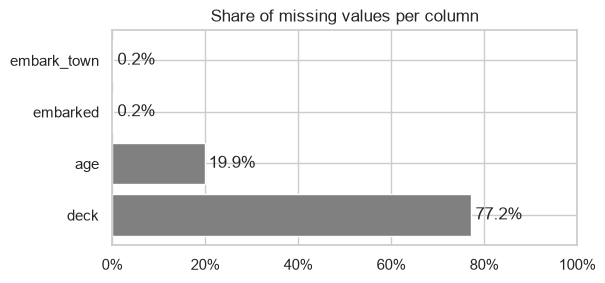

In [54]:
from statsmodels.stats.proportion import proportion_confint

df = sns.load_dataset("titanic")
insights = []                                                             # every sentence of the report is appended by code

missing_share = df.isna().mean().sort_values(ascending=False)
missing_share = missing_share[missing_share > 0]
n_duplicates = int(df.duplicated().sum())
print(f"{len(df)} rows × {df.shape[1]} columns | exact duplicate rows: {n_duplicates}")
print(missing_share.round(3))

mostly_missing = missing_share[missing_share > 0.5]
if len(mostly_missing):
    listed = ", ".join(f"`{c}` ({s:.0%})" for c, s in mostly_missing.items())
    insights.append(f"The data has {len(df)} passengers; {len(missing_share)} columns have missing values, and {listed} "
                    f"{'is' if len(mostly_missing) == 1 else 'are'} more than half missing.")
else:
    insights.append(f"The data has {len(df)} passengers; {len(missing_share)} columns have missing values, none of them more than half missing.")
insights.append(f"{n_duplicates} rows are exact duplicates of another row; with no name or ticket column they may still be different passengers, so they are kept.")

fig, ax = plt.subplots(figsize=(6, 2.8))
ax.barh(missing_share.index, missing_share.values, color="gray")
ax.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=1))
ax.bar_label(ax.containers[0], fmt="{:.1%}", padding=3)
ax.set(title="Share of missing values per column", xlim=(0, 1))
plt.show()

### Step 2 — Target and key distributions

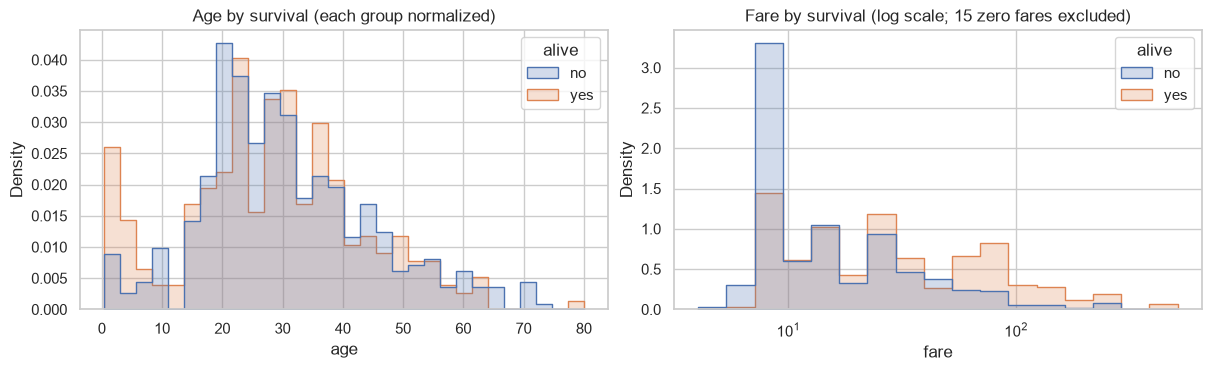

In [55]:
overall_rate = df["survived"].mean()
insights.append(f"Overall, {overall_rate:.1%} of passengers survived ({df['survived'].sum()} of {len(df)}).")

zero_fares = int((df["fare"] == 0).sum())
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), layout="constrained")
sns.histplot(data=df, x="age", hue="alive", bins=30, stat="density", common_norm=False, element="step", ax=axes[0])
axes[0].set_title("Age by survival (each group normalized)")
sns.histplot(data=df[df["fare"] > 0], x="fare", hue="alive", log_scale=True, stat="density", common_norm=False, element="step", ax=axes[1])
axes[1].set_title(f"Fare by survival (log scale; {zero_fares} zero fares excluded)")
plt.show()

fare_corr = stats.spearmanr(df["fare"], df["survived"])
insights.append(f"Fare is {'positively' if fare_corr.statistic > 0 else 'negatively'} associated with survival "
                f"(Spearman ρ = {fare_corr.statistic:+.2f}, p = {fare_corr.pvalue:.1g}); fares are heavily right-skewed "
                f"(skewness {stats.skew(df['fare']):.1f}), so a log scale is needed to see the distribution.")

### Step 3 — Survival by group, with 95% confidence intervals

A rate from 77 passengers is much less certain than one from 644. We attach **Wilson 95% confidence intervals** (from the Statistics notebook) so small groups don't get over-interpreted.

        survivors    n   rate  ci_low  ci_high
sex                                           
female        233  314  0.742   0.691    0.787
male          109  577  0.189   0.159    0.223 

        survivors    n   rate  ci_low  ci_high
class                                         
First         136  216  0.630   0.563    0.691
Second         87  184  0.473   0.402    0.545
Third         119  491  0.242   0.207    0.282 

             survivors    n   rate  ci_low  ci_high
embark_town                                        
Cherbourg           93  168  0.554   0.478    0.627
Queenstown          30   77  0.390   0.288    0.501
Southampton        217  644  0.337   0.302    0.374 



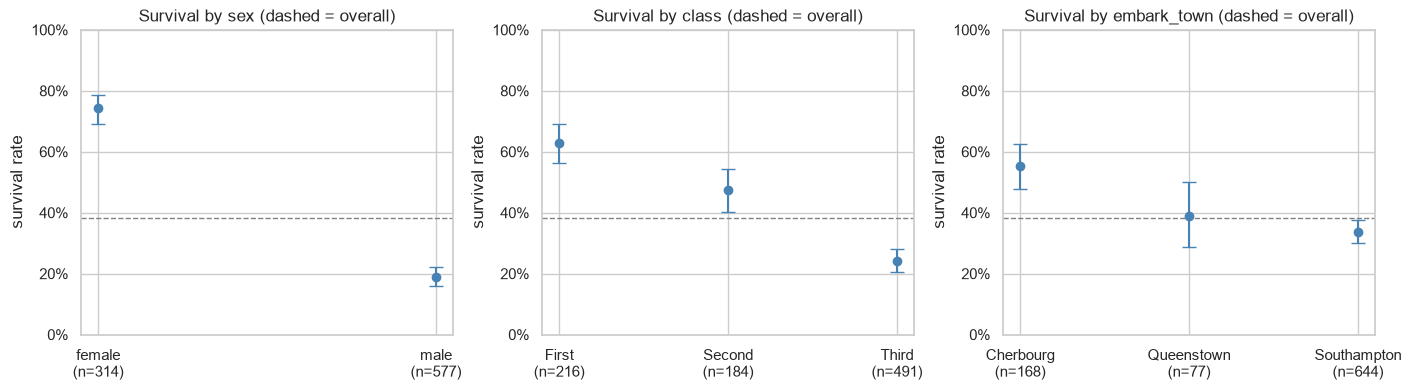

In [56]:
def survival_table(data, column):
    grouped = data.groupby(column, observed=True)["survived"].agg(survivors="sum", n="size")
    low, high = proportion_confint(grouped["survivors"], grouped["n"], method="wilson")
    return grouped.assign(rate=grouped["survivors"] / grouped["n"], ci_low=low, ci_high=high)


def plot_rates(ax, table, title):
    x = np.arange(len(table))
    ax.errorbar(x, table["rate"], yerr=[table["rate"] - table["ci_low"], table["ci_high"] - table["rate"]], fmt="o", capsize=5, color="steelblue")
    ax.axhline(overall_rate, color="gray", ls="--", lw=1)
    ax.set_xticks(x, labels=[f"{name}\n(n={n})" for name, n in zip(table.index.astype(str), table["n"])])
    ax.set(title=title, ylim=(0, 1), ylabel="survival rate")
    ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=1))


tables = {col: survival_table(df, col) for col in ["sex", "class", "embark_town"]}
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), layout="constrained")
for ax, (col, table) in zip(axes, tables.items()):
    plot_rates(ax, table, f"Survival by {col} (dashed = overall)")
    print(table.round(3), "\n")
plt.show()

for col, table in tables.items():
    best, worst = table["rate"].idxmax(), table["rate"].idxmin()
    separated = table.loc[best, "ci_low"] > table.loc[worst, "ci_high"]
    insights.append(f"By {col}: highest survival for {best} ({table.loc[best, 'rate']:.1%}, n={table.loc[best, 'n']}), "
                    f"lowest for {worst} ({table.loc[worst, 'rate']:.1%}, n={table.loc[worst, 'n']}); "
                    f"the 95% CIs {'do not overlap' if separated else 'overlap, so treat the gap with caution'}.")

### Step 4 — Interactions: class × sex and age × sex

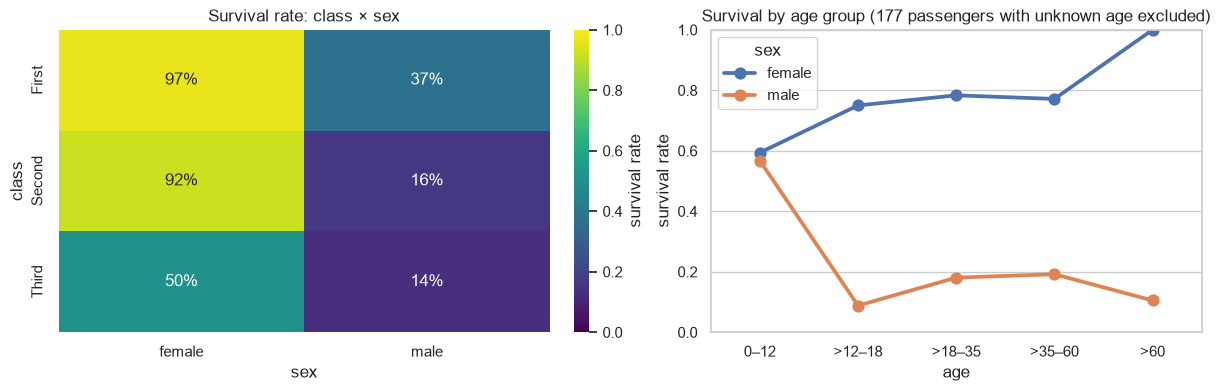

age_group    sex  mean  size
     0–12 female 0.594    32
     0–12   male 0.568    37
   >12–18 female 0.750    36
   >12–18   male 0.088    34
   >18–35 female 0.783   120
   >18–35   male 0.181   238
   >35–60 female 0.771    70
   >35–60   male 0.192   125
      >60 female 1.000     3
      >60   male 0.105    19


In [57]:
class_sex = df.pivot_table(index="class", columns="sex", values="survived", aggfunc="mean", observed=True)
age_groups = pd.cut(df["age"], bins=[0, 12, 18, 35, 60, 80], include_lowest=True,
                    labels=["0–12", ">12–18", ">18–35", ">35–60", ">60"])
age_sex = df.assign(age_group=age_groups).groupby(["age_group", "sex"], observed=True)["survived"].agg(["mean", "size"]).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), layout="constrained")
sns.heatmap(class_sex, annot=True, fmt=".0%", cmap="viridis", vmin=0, vmax=1, cbar_kws={"label": "survival rate"}, ax=axes[0])
axes[0].set_title("Survival rate: class × sex")
sns.pointplot(data=age_sex, x="age_group", y="mean", hue="sex", ax=axes[1])
axes[1].set(title=f"Survival by age group ({df['age'].isna().sum()} passengers with unknown age excluded)", xlabel="age", ylabel="survival rate", ylim=(0, 1))
plt.show()
print(age_sex.round(3).to_string(index=False))

third_women, first_men = class_sex.loc["Third", "female"], class_sex.loc["First", "male"]
if third_women > first_men:
    insights.append(f"Sex outweighed class at the extremes: third-class women survived at {third_women:.0%}, "
                    f"higher than first-class men ({first_men:.0%}).")
else:
    insights.append(f"Class outweighed sex at the extremes: first-class men survived at {first_men:.0%}, "
                    f"at least as often as third-class women ({third_women:.0%}).")
male_rates = age_sex[age_sex["sex"] == "male"].set_index("age_group")["mean"]
insights.append(f"Among males, the {male_rates.idxmax()} age group had the highest survival rate ({male_rates.max():.0%}) "
                f"and the {male_rates.idxmin()} group the lowest ({male_rates.min():.0%}).")

### Step 5 — Family size

        survivors    n   rate  ci_low  ci_high
family                                        
alone         163  537  0.304   0.266    0.344
2–4           169  292  0.579   0.521    0.634
5+             10   62  0.161   0.090    0.272


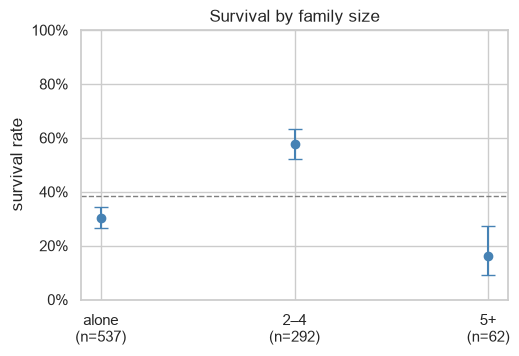

In [58]:
family_size = df["sibsp"] + df["parch"] + 1
family_group = pd.cut(family_size, bins=[0, 1, 4, 11], labels=["alone", "2–4", "5+"])
family = survival_table(df.assign(family=family_group), "family")
print(family.round(3))

fig, ax = plt.subplots(figsize=(5.5, 3.5))
plot_rates(ax, family, "Survival by family size")
plt.show()

insights.append(f"Family size: {family['rate'].idxmax()} had the highest survival ({family['rate'].max():.0%}), "
                f"passengers travelling alone {family.loc['alone', 'rate']:.0%}, and large families (5+) {family.loc['5+', 'rate']:.0%} — "
                f"{'not a straight-line relationship' if family['rate'].idxmax() == '2–4' else 'a monotonic pattern'}.")

### Step 6 — Correlations with survival

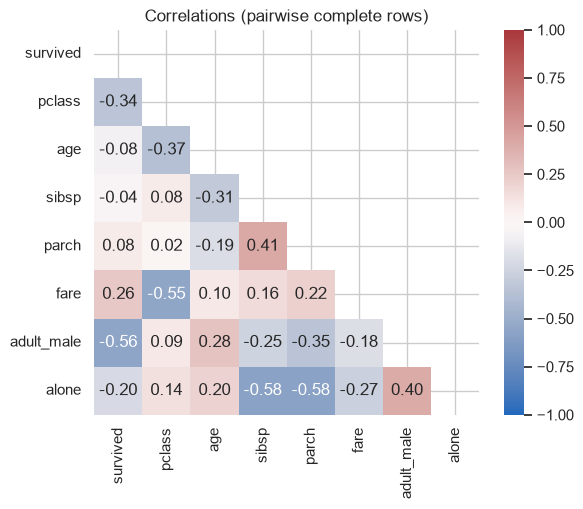

In [59]:
numeric = df[["survived", "pclass", "age", "sibsp", "parch", "fare", "adult_male", "alone"]].astype(float)
corr_titanic = numeric.corr()
fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(corr_titanic, mask=np.triu(np.ones_like(corr_titanic, dtype=bool)), annot=True, fmt=".2f",
            cmap="vlag", vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title("Correlations (pairwise complete rows)")
plt.show()

with_target = corr_titanic["survived"].drop("survived")
top_feature = with_target.abs().idxmax()
insights.append(f"The feature most correlated with survival is `{top_feature}` (r = {with_target[top_feature]:+.2f}); "
                f"next is `{with_target.drop(top_feature).abs().idxmax()}` (r = {with_target[with_target.drop(top_feature).abs().idxmax()]:+.2f}).")

### Step 7 — Dashboard and report

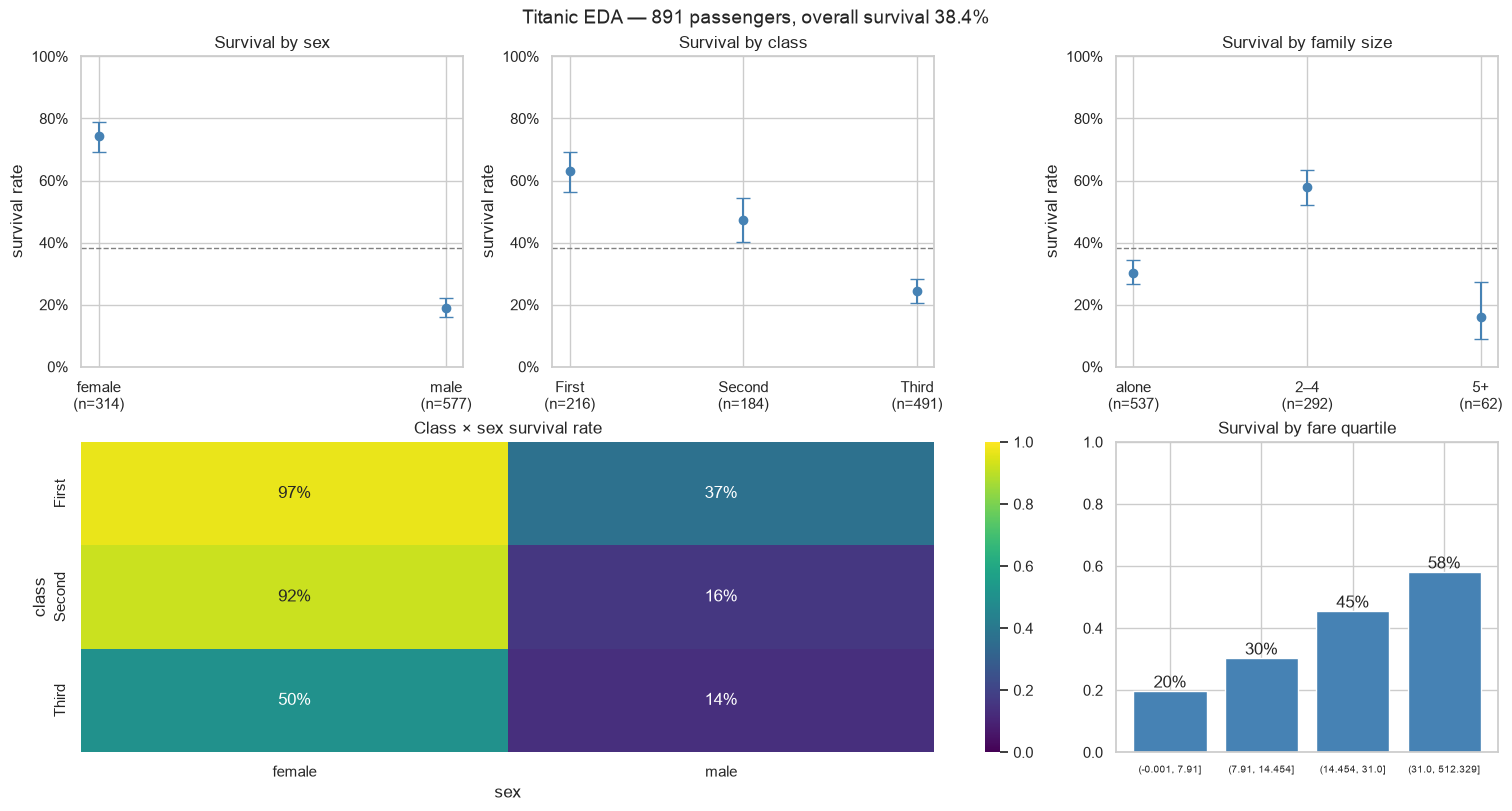

# Titanic EDA — key findings

1. The data has 891 passengers; 4 columns have missing values, and `deck` (77%) is more than half missing.
2. 107 rows are exact duplicates of another row; with no name or ticket column they may still be different passengers, so they are kept.
3. Overall, 38.4% of passengers survived (342 of 891).
4. Fare is positively associated with survival (Spearman ρ = +0.32, p = 3e-23); fares are heavily right-skewed (skewness 4.8), so a log scale is needed to see the distribution.
5. By sex: highest survival for female (74.2%, n=314), lowest for male (18.9%, n=577); the 95% CIs do not overlap.
6. By class: highest survival for First (63.0%, n=216), lowest for Third (24.2%, n=491); the 95% CIs do not overlap.
7. By embark_town: highest survival for Cherbourg (55.4%, n=168), lowest for Southampton (33.7%, n=644); the 95% CIs do not overlap.
8. Sex outweighed class at the extremes: third-class women survived at 50%, higher than first-class men (37%).
9. Among males, th

In [60]:
fig, axd = plt.subplot_mosaic([["sex", "class", "family"], ["heat", "heat", "fare"]], figsize=(15, 8), layout="constrained")
plot_rates(axd["sex"], tables["sex"], "Survival by sex")
plot_rates(axd["class"], tables["class"], "Survival by class")
plot_rates(axd["family"], family, "Survival by family size")
sns.heatmap(class_sex, annot=True, fmt=".0%", cmap="viridis", vmin=0, vmax=1, ax=axd["heat"])
axd["heat"].set_title("Class × sex survival rate")
fare_by_quartile = df.groupby(pd.qcut(df["fare"], 4), observed=True)["survived"].mean()
axd["fare"].bar([str(interval) for interval in fare_by_quartile.index], fare_by_quartile.values, color="steelblue")
axd["fare"].bar_label(axd["fare"].containers[0], fmt="{:.0%}")
axd["fare"].set(title="Survival by fare quartile", ylim=(0, 1))
axd["fare"].tick_params(axis="x", labelsize=7)
fig.suptitle(f"Titanic EDA — {len(df)} passengers, overall survival {overall_rate:.1%}", fontsize=14)
dashboard_path = OUTPUT_DIR / "titanic_eda_dashboard.png"
fig.savefig(dashboard_path, dpi=150, bbox_inches="tight")
plt.show()

report = "# Titanic EDA — key findings\n\n" + "\n".join(f"{i}. {text}" for i, text in enumerate(insights, 1)) + f"\n\n![dashboard]({dashboard_path.name})\n"
report_path = OUTPUT_DIR / "titanic_eda_report.md"
report_path.write_text(report)
print(report)
print(f"saved {dashboard_path} and {report_path}")

**Stretch goals**
1. Back each group comparison with a **chi-square test** (see the Statistics notebook) and add the p-value to the insight sentence — with a multiple-testing correction.
2. Turn Steps 1–6 into a reusable `eda_report(df, target)` function and run it on `penguins` with `species` as the target.
3. Add a missing-value **pattern** plot (which columns are missing together) and check whether `age` is missing at random with respect to survival.
4. Recreate the dashboard in Plotly (next notebook) with hover tooltips.

### 🗣️ How to talk about this in an interview
- "I built an EDA where **every insight sentence is generated from the data**, so the report can't drift from the numbers when the data changes."
- "I started with **data quality** — missingness per column and duplicates — before any charts about the target."
- "For group comparisons I showed **rates with Wilson 95% confidence intervals** and sample sizes, so a small group like Queenstown isn't over-interpreted."
- "I looked for **interactions** (class × sex, age × sex) instead of stopping at one-variable breakdowns, and used a log scale for the skewed fare."
- "Everything is saved as a dashboard PNG and a Markdown report, which is what I'd hand to a stakeholder."

## 🎤 Interview Q&A

Try answering **out loud** before opening each answer.

### 🧠 Concepts

**Q1. What is the difference between a Figure, an Axes, and an Axis — and why prefer the object-oriented API?**

<details><summary>Show answer</summary>

- **30-second answer:** The Figure is the whole canvas; an Axes is one plot area with its own coordinates; an Axis is the x or y ruler. The OO API (`fig, ax = plt.subplots()`; `ax.plot`) targets an explicit Axes instead of pyplot's hidden "current" one.
- **Go deeper:** Explicit handles make multi-panel figures predictable and let you write functions like `plot_x(ax, data)` that compose into any layout and are easy to test. pyplot is fine for a quick interactive look.
- **❌ Common wrong answer:** "Axes is the plural of axis."

</details>

**Q2. How do you choose a chart type?**

<details><summary>Show answer</summary>

- **30-second answer:** From the question: distribution → histogram/ECDF/violin; comparison of categories → sorted bar or dot plot; trend → line; relationship → scatter; composition → stacked bar; many variables → heatmap or small multiples.
- **Go deeper:** People judge position and length on a common scale most accurately, angle and area least — which is why bars beat pies. Show uncertainty (CIs) when comparing estimates, and avoid dual y-axes and truncated bar baselines that exaggerate differences.
- **❌ Common wrong answer:** "Whatever looks most impressive" or defaulting to pie charts for comparisons.

</details>

**Q3. Seaborn axes-level vs figure-level functions — what's the difference?**

<details><summary>Show answer</summary>

- **30-second answer:** Axes-level functions (`scatterplot`, `histplot`, `boxplot`) draw on one Matplotlib Axes you can pass in. Figure-level functions (`relplot`, `displot`, `catplot`, `lmplot`) create their own figure, return a `FacetGrid`, and can facet with `col`/`row`.
- **Go deeper:** Size figure-level plots with `height` and `aspect`; access `g.figure` and `g.axes` to customize. Use axes-level functions inside `plt.subplots`/`subplot_mosaic` layouts.
- **❌ Common wrong answer:** "They're aliases" or "pass `figsize` to `catplot`".

</details>

**Q4. Why is `viridis` preferred over `jet`?**

<details><summary>Show answer</summary>

- **30-second answer:** Viridis is perceptually uniform with lightness rising monotonically, so equal data steps look equal, it survives grayscale printing, and it works for most colour-vision deficiencies. Jet's lightness rises and falls, creating false bands and hiding real structure.
- **Go deeper:** Use sequential maps for ordered data, diverging maps (with symmetric limits) for data around a meaningful midpoint like 0 correlation, and qualitative palettes for categories — plus redundant markers so colour isn't the only cue.
- **❌ Common wrong answer:** "Jet has more colours so it shows more detail."

</details>

**Q5. When would you use a precision–recall curve instead of a ROC curve?**

<details><summary>Show answer</summary>

- **30-second answer:** When the positive class is rare and you care about the quality of positive predictions (fraud, disease, search). PR curves show precision directly and their chance line is the prevalence; ROC can look excellent because the false-positive *rate* is divided by a huge number of negatives.
- **Go deeper:** ROC AUC is threshold-free and insensitive to class balance (good for comparing rankers); average precision summarises the PR curve. Choose the operating threshold from business costs, not from the curve alone.
- **❌ Common wrong answer:** "ROC AUC of 0.95 always means the model is good in production."

</details>

**Q6. How do you read a learning curve?**

<details><summary>Show answer</summary>

- **30-second answer:** Plot training and validation scores against training-set size. A big, persistent gap (high train, lower validation) means **high variance** — more data, regularization, or a simpler model help. Both scores low and close means **high bias** — use a more expressive model or better features.
- **Go deeper:** If validation is still rising at the largest size, more data will likely help; if it has plateaued, it won't. Compute the curve with cross-validation inside the training set so the test set stays untouched.
- **❌ Common wrong answer:** Plotting loss vs epochs and calling it a learning curve for data-size decisions (that's a training curve — related, but it answers a different question).

</details>

**Q7. Histogram vs KDE vs ECDF — trade-offs?**

<details><summary>Show answer</summary>

- **30-second answer:** Histograms are simple but depend on bin width and start; KDEs are smooth but depend on bandwidth and can put density where data can't be (below 0); ECDFs have no tuning parameters and make medians/percentiles and group comparisons exact, but are less intuitive for shape.
- **Go deeper:** Scott's rule bandwidth $h = s\,n^{-1/5}$ over-smooths multimodal data; try `bw_adjust`. For bounded data use `clip` or a log transform.
- **❌ Common wrong answer:** "A KDE is the true distribution."

</details>

### 💻 Coding

**Q8. Plot a confusion matrix with counts and per-class recall percentages.**

<details><summary>Show answer</summary>

- **30-second answer:** `cm = confusion_matrix(y_true, y_pred); pct = cm / cm.sum(axis=1, keepdims=True); sns.heatmap(pct, annot=labels, fmt="", cmap="Blues", vmin=0, vmax=1)` with `labels` combining counts and percentages; label axes "predicted" (columns) and "true" (rows).
- **Go deeper:** Or `ConfusionMatrixDisplay.from_predictions(y_true, y_pred, normalize="true")`. Row-normalizing shows recall per class; column-normalizing shows precision per predicted class.
- **❌ Common wrong answer:** Swapping rows and columns (sklearn's rows are the true labels) or normalizing by the grand total.

</details>

**Q9. Create a 2×2 figure with shared axes, a title, and save it for a paper.**

<details><summary>Show answer</summary>

- **30-second answer:** `fig, axes = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(7, 5), layout="constrained")`; draw with `axes[r, c]`; `fig.suptitle(...)`; `fig.savefig("fig.pdf")` (vector) or `fig.savefig("fig.png", dpi=300, bbox_inches="tight")`; then `plt.close(fig)`.
- **Go deeper:** Pixel size = inches × dpi. Rasterize dense scatter layers (`rasterized=True`) inside vector files to keep them small.
- **❌ Common wrong answer:** Calling `plt.title` after creating several subplots (it only titles the last Axes).

</details>

### 🐛 Debugging Scenarios

**Q10. A batch job that saves 5,000 plots gets slower and eventually runs out of memory. Why?**

<details><summary>Show answer</summary>

- **30-second answer:** pyplot keeps every figure alive until it's closed. Call `plt.close(fig)` after `savefig` (or create figures with `matplotlib.figure.Figure` directly), and use the non-interactive Agg backend on servers.
- **Go deeper:** Matplotlib warns "More than 20 figures have been opened". Reusing one figure and clearing Axes (`ax.clear()`) is faster still.
- **❌ Common wrong answer:** "Call `plt.show()` to free the memory."

</details>

**Q11. `ax.axhline(0.5, transform=ax.transAxes)` raises an error, and a `with plt.style.context(...)` block didn't change your plot. What happened in each case?**

<details><summary>Show answer</summary>

- **30-second answer:** `axhline` always uses data coordinates for y and axes fractions for x, so it rejects a `transform`; use `ax.axhline(y_data, xmin=…, xmax=…)`. A style context only affects Artists and Axes **created inside** the block — create the figure inside the `with`.
- **Go deeper:** For a line at a fraction of the Axes height, use `ax.plot([0, 1], [0.5, 0.5], transform=ax.transAxes)`.
- **❌ Common wrong answer:** "Matplotlib bug — restart the kernel."

</details>

**Q12. Your PCA/t-SNE plot shows clean, separated clusters. Can you conclude the classes are easy to separate?**

<details><summary>Show answer</summary>

- **30-second answer:** Not from that alone. PCA shows only the top-variance linear directions (report the explained variance); t-SNE/UMAP can create or exaggerate clusters, and their inter-cluster distances and sizes are not meaningful. Confirm with a proper model evaluated on held-out data.
- **Go deeper:** t-SNE results change with perplexity and random seed — always compare several runs. Overlap in 2-D doesn't imply overlap in the full space either.
- **❌ Common wrong answer:** "Distance between t-SNE clusters shows how different the classes are."

</details>

### 🏗️ Design

**Q13. Design a dashboard to monitor a production classification model.**

<details><summary>Show answer</summary>

- **30-second answer:** Small multiples over time: prediction volume and latency percentiles (p50/p95/p99), the score distribution vs a training reference, per-feature drift (histograms or PSI) for the top features, label-delayed metrics (precision, recall, calibration curve) with confidence bands, and a confusion matrix per key segment — with threshold lines for alerts.
- **Go deeper:** Use consistent colours per model version, log scales for latency, annotations for deploys, and link each alert to a drill-down. Monitor data quality (null rates, schema) separately from model quality.
- **❌ Common wrong answer:** "One accuracy number on a big screen."

</details>

## 🧪 Quick Quiz

Predict the output, then reveal.

**1.** `fig, axes = plt.subplots(2, 3); axes.shape`
<details><summary>Answer</summary>

`(2, 3)` — a NumPy array of Axes, indexed `axes[row, col]`.
</details>

**2.** A figure with `figsize=(6, 4)` is saved with `dpi=100` (no `bbox_inches="tight"`). How many pixels wide × tall is the PNG?
<details><summary>Answer</summary>

`600 × 400` — pixels = inches × dpi.
</details>

**3.** What type does `sns.relplot(data=tips, x="total_bill", y="tip", col="time")` return?
<details><summary>Answer</summary>

A `FacetGrid` — figure-level functions return a grid object, not an Axes.
</details>

**4.** `np.histogram([1, 2, 2, 3, 3, 3], bins=3)[0]`
<details><summary>Answer</summary>

`array([1, 2, 3])` — edges are 1, 1.67, 2.33, 3, and the last bin includes its right edge (3).
</details>

**5.** `pd.cut([18, 25, 40], bins=[18, 30, 50])[0]`
<details><summary>Answer</summary>

`NaN` — intervals are right-closed, `(18, 30]`, so 18 is excluded unless you pass `include_lowest=True`.
</details>

## 📚 Resources

### 📖 Official Docs
- [Matplotlib — Quick start guide](https://matplotlib.org/stable/users/explain/quick_start.html) — Figure/Axes anatomy and the two APIs
- [Matplotlib Application Interfaces (APIs)](https://matplotlib.org/stable/users/explain/figure/api_interfaces.html) — pyplot vs object-oriented, explained by the maintainers
- [Choosing Colormaps in Matplotlib](https://matplotlib.org/stable/users/explain/colors/colormaps.html) — sequential, diverging, qualitative, and lightness plots
- [Constrained layout guide](https://matplotlib.org/stable/users/explain/axes/constrainedlayout_guide.html) and [Complex and semantic figure composition (subplot_mosaic)](https://matplotlib.org/stable/users/explain/axes/mosaic.html)
- [Overview of seaborn plotting functions](https://seaborn.pydata.org/tutorial/function_overview.html) — axes-level vs figure-level
- [Choosing color palettes](https://seaborn.pydata.org/tutorial/color_palettes.html) — seaborn's palette guide
- [scikit-learn — Visualizations](https://scikit-learn.org/stable/visualizations.html) — the `Display` objects for ROC, PR, confusion matrix, and residuals

### 🎥 Videos
- [Corey Schafer — Matplotlib Tutorial (Part 1): Creating and Customizing Our First Plots](https://www.youtube.com/watch?v=UO98lJQ3QGI) (35 min) — clear, practical start to a well-known series
- [Derek Banas — Seaborn Tutorial : Seaborn Full Course](https://www.youtube.com/watch?v=6GUZXDef2U0) (1 h) — tour of seaborn's plot types to watch alongside Sections 9–12
- [StatQuest (Josh Starmer) — ROC and AUC, Clearly Explained!](https://www.youtube.com/watch?v=4jRBRDbJemM) (16 min) — the intuition behind the curves in Section 13c

### 📄 Papers
- [Waskom (2021) — seaborn: statistical data visualization](https://joss.theoj.org/papers/10.21105/joss.03021) — seaborn's design, by its author (JOSS)
- [Saito & Rehmsmeier (2015) — The Precision-Recall Plot Is More Informative than the ROC Plot When Evaluating Binary Classifiers on Imbalanced Datasets](https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0118432) — the evidence behind Q5
- [Wattenberg, Viégas & Johnson (2016) — How to Use t-SNE Effectively](https://distill.pub/2016/misread-tsne/) — interactive article on misreading embeddings

### 📘 Books & Courses
- [Fundamentals of Data Visualization](https://clauswilke.com/dataviz/) — Claus O. Wilke's free book on choosing and designing charts
- [Scientific Visualization: Python + Matplotlib (rougier/scientific-visualization-book)](https://github.com/rougier/scientific-visualization-book) — free, deep Matplotlib book by Nicolas Rougier
- [Python Data Science Handbook — Visualization with Matplotlib](https://jakevdp.github.io/PythonDataScienceHandbook/04.00-introduction-to-matplotlib.html) — Jake VanderPlas, free online

### 🏋️ Practice
- [Kaggle Learn — Data Visualization](https://www.kaggle.com/learn/data-visualization) — short, hands-on seaborn exercises
- [From data to Viz](https://www.data-to-viz.com/) — a decision tree for picking the right chart, with caveats for each
- [Matplotlib cheatsheets](https://matplotlib.org/cheatsheets/) — one-page references to keep open

### 🗂️ Datasets used
- [seaborn-data (mwaskom/seaborn-data)](https://github.com/mwaskom/seaborn-data) — `penguins`, `tips`, `flights`, `titanic`, `diamonds` · [palmerpenguins](https://allisonhorst.github.io/palmerpenguins/) — origin of the penguins data

## 📝 Summary Cheat Sheet

| Concept | What it does | Key API |
|---|---|---|
| OO API | explicit figure/axes handles | `fig, ax = plt.subplots()`, `ax.plot/scatter/bar/hist/boxplot`, `ax.set(...)` |
| Layout | multi-panel figures without overlap | `plt.subplots(r, c, layout="constrained")`, `plt.subplot_mosaic([["a", "b"], ["c", "c"]])` |
| Annotate | explain the chart on the chart | `ax.annotate`, `ax.axhline(y)`, `ax.axvspan`, `ax.text(..., transform=ax.transAxes)`, `ax.bar_label(fmt="{:.1%}")` |
| Scales & ticks | readable skewed data | `ax.set_xscale("log")`, `np.geomspace` bins, `StrMethodFormatter`, `PercentFormatter` |
| Colour | honest, accessible colour | `viridis`/`cividis` (sequential), `vlag` with `vmin=-1, vmax=1` (diverging), `"colorblind"` palette; `mpl.colormaps[...]` |
| Style & save | consistent look, right output | `with plt.style.context(...)` *before* creating; `fig.savefig(path, dpi=300, bbox_inches="tight")`, `.svg/.pdf`; `plt.close(fig)` |
| Seaborn basics | data-first plotting | `data=, x=, y=, hue=, style=, col=`; axes-level (`ax=`) vs figure-level (`height=, aspect=`, `g.figure`) |
| Distributions | shape of data | `histplot`, `kdeplot`, `ecdfplot`, `displot` |
| Categorical | compare groups | `violinplot`, `boxenplot`, `stripplot`, `barplot(errorbar=("ci", 95))`, `countplot`, `catplot` |
| Relational & regression | relationships and trends | `scatterplot`, `lineplot`, `relplot`, `regplot`, `lmplot` |
| Matrix & grids | many variables | `heatmap(mask=…, annot=True)`, `pairplot`, `FacetGrid.map_dataframe`, `jointplot` |
| ML diagnostics | debug and explain models | `learning_curve`, `confusion_matrix` + heatmap, `RocCurveDisplay`, `PrecisionRecallDisplay`, `PredictionErrorDisplay`, `permutation_importance`, `PCA` |

## ➡️ What's Next

**[02 · Plotly (optional)](02_Plotly.ipynb)** — make the same charts interactive with hover, zoom, and dashboards for the browser.

**[03 · Classical ML — ML Fundamentals From Scratch](../03_Classical_Machine_Learning/01_ML_Fundamentals_From_Scratch.ipynb)** — you can now *see* data and model behaviour; next you'll build regression, logistic regression, and evaluation metrics yourself and use these diagnostic plots to understand them.